In [1]:
import pandas as pd
import numpy as np

# Load the CSV
df = pd.read_csv("/zfsauton/data/straps/UBFC-rPPG/UBFC_DATASET/results/CHROM_UBFC-rPPG/raw_predictions_per_window.csv", sep=",")  # adjust sep="," if it's comma-separated instead of tab

# Create an error column (Predicted - Ground Truth)
df["error"] = df["predicted_hr"] - df["ground_truth_hr"]

# Absolute error in bpm
df["abs_error"] = df["error"].abs()

# Check accuracy within thresholds
acc_5bpm = (df["abs_error"] <= 5).mean() * 100
acc_3bpm = (df["abs_error"] <= 3).mean() * 100
acc_1bpm = (df["abs_error"] <= 1).mean() * 100

print(f"Accuracy within 5 bpm: {acc_5bpm:.2f}%")
print(f"Accuracy within 3 bpm: {acc_3bpm:.2f}%")
print(f"Accuracy within 1 bpm: {acc_1bpm:.2f}%")


Accuracy within 5 bpm: 89.40%
Accuracy within 3 bpm: 79.15%
Accuracy within 1 bpm: 79.15%


threshold_bpm,acc_1bpm(%),acc_3bpm(%),acc_5bpm(%),acc_10bpm(%)
method,,,,
CHROM,79.15,79.15,89.40,92.23
GREEN,51.59,51.59,59.72,62.90
ICA,59.36,59.36,67.14,69.96
LGI,67.84,67.84,75.27,77.74
OMIT,68.55,68.55,75.97,78.09
PBV,62.54,62.54,69.26,71.73
POS,81.98,81.98,91.17,93.64


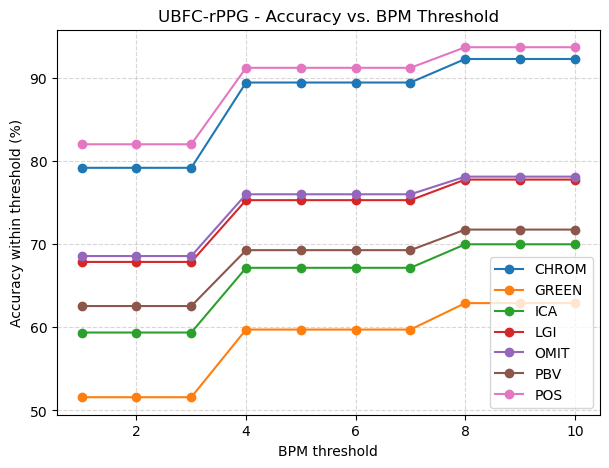

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ----------------------------
# 1) Point these to your files
# ----------------------------
# Example: map method name -> CSV path
method_files = {
    "CHROM": "/zfsauton/data/straps/UBFC-rPPG/UBFC_DATASET/results/CHROM_UBFC-rPPG/raw_predictions_per_window.csv",
    "GREEN": "/zfsauton/data/straps/UBFC-rPPG/UBFC_DATASET/results/GREEN_UBFC-rPPG/raw_predictions_per_window.csv",
    "ICA": "/zfsauton/data/straps/UBFC-rPPG/UBFC_DATASET/results/ICA_UBFC-rPPG/raw_predictions_per_window.csv",
    "LGI": "/zfsauton/data/straps/UBFC-rPPG/UBFC_DATASET/results/LGI_UBFC-rPPG/raw_predictions_per_window.csv",
    "OMIT": "/zfsauton/data/straps/UBFC-rPPG/UBFC_DATASET/results/OMIT_UBFC-rPPG/raw_predictions_per_window.csv",
    "PBV": "/zfsauton/data/straps/UBFC-rPPG/UBFC_DATASET/results/PBV_UBFC-rPPG/raw_predictions_per_window.csv",
    "POS": "/zfsauton/data/straps/UBFC-rPPG/UBFC_DATASET/results/POS_UBFC-rPPG/raw_predictions_per_window.csv",
    "TSCAN": "/zfsauton/data/straps/UBFC-rPPG/UBFC_DATASET/results/TSCAN_UBFC-rPPG/raw_predictions_per_window.csv"
}

# If your CSVs are tab-separated (like your excerpt), leave sep=None (auto-infer) with engine="python"
read_kwargs = dict(sep=None, engine="python")  # change to sep="," if strictly comma-separated

# ---------------------------------------------
# 2) Helper: load and standardize one CSV frame
# ---------------------------------------------
def load_results(method_name, path):
    df = pd.read_csv(path, **read_kwargs)
    # Normalize likely column names (edit here if yours differ)
    # Expected columns: predicted_hr, ground_truth_hr
    # If yours are named differently, adjust the mapping below.
    rename_map = {
        "predicted_hr": "predicted_hr",
        "ground_truth_hr": "ground_truth_hr",
        "participant_id": "participant_id",
        "window_index": "window_index",
    }
    # only rename columns that actually exist
    rename_map = {k: v for k, v in rename_map.items() if k in df.columns}
    df = df.rename(columns=rename_map)

    # Basic checks
    required = {"predicted_hr", "ground_truth_hr"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{method_name}: Missing columns {missing} in {path}")

    df["method"] = method_name
    df["abs_error"] = (df["predicted_hr"] - df["ground_truth_hr"]).abs()
    return df

# ----------------------------------------
# 3) Load all methods into a single table
# ----------------------------------------
frames = []
for m, p in method_files.items():
    if not Path(p).exists():
        raise FileNotFoundError(f"File not found for method '{m}': {p}")
    frames.append(load_results(m, p))

all_df = pd.concat(frames, ignore_index=True)

# ---------------------------------------------------
# 4) Compute accuracy curve for thresholds 1..10 bpm
# ---------------------------------------------------
thresholds = np.arange(1, 11)  # 1,2,...,10 bpm
rows = []
for method, g in all_df.groupby("method"):
    for t in thresholds:
        acc = (g["abs_error"] <= t).mean() * 100.0  # percentage
        rows.append({"method": method, "threshold_bpm": t, "accuracy_pct": acc})

acc_curve = pd.DataFrame(rows)

# -------------------------------------------------------------
# 5) Also print the headline numbers (1, 3, 5, and 10 bpm)
# -------------------------------------------------------------
headline_ts = [1, 3, 5, 10]
headline = (
    acc_curve[acc_curve["threshold_bpm"].isin(headline_ts)]
    .pivot(index="method", columns="threshold_bpm", values="accuracy_pct")
    .rename(columns={1: "acc_1bpm(%)", 3: "acc_3bpm(%)", 5: "acc_5bpm(%)", 10: "acc_10bpm(%)"})
    .sort_index()
)
display(headline.round(2))

# ------------------------------------------------
# 6) Plot: accuracy vs bpm threshold (per method)
# ------------------------------------------------
plt.figure(figsize=(7, 5))
for method, g in acc_curve.groupby("method"):
    g = g.sort_values("threshold_bpm")
    plt.plot(g["threshold_bpm"], g["accuracy_pct"], marker="o", label=method)

plt.xlabel("BPM threshold")
plt.ylabel("Accuracy within threshold (%)")
plt.title("UBFC-rPPG - Accuracy vs. BPM Threshold")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.show()


threshold_bpm,acc_1bpm(%),acc_3bpm(%),acc_5bpm(%),acc_10bpm(%)
method,,,,
CHROM,68.81,82.80,84.86,88.07
DeepPhys,56.62,70.83,73.53,78.19
EfficientPhys,62.99,79.41,81.86,86.27
GREEN,44.04,60.09,64.91,74.77
ICA,76.83,88.30,89.68,91.97
LGI,73.62,88.53,89.91,93.58
OMIT,73.17,88.53,89.91,94.04
PBV,57.11,74.08,77.98,85.32
POS,79.82,91.97,93.81,96.10


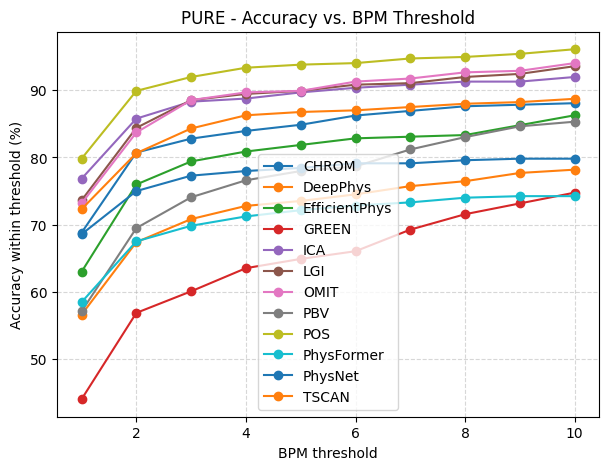

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ----------------------------
# 1) Point these to your files
# ----------------------------
# Example: map method name -> CSV path
method_files = {
    "CHROM": "/zfsauton/data/straps/PURE/resultsFineFFT/CHROM_PURE/raw_predictions_per_window.csv",
    "GREEN": "/zfsauton/data/straps/PURE/resultsFineFFT/GREEN_PURE/raw_predictions_per_window.csv",
    "ICA": "/zfsauton/data/straps/PURE/resultsFineFFT/ICA_PURE/raw_predictions_per_window.csv",
    "LGI": "/zfsauton/data/straps/PURE/resultsFineFFT/LGI_PURE/raw_predictions_per_window.csv",
    "OMIT": "/zfsauton/data/straps/PURE/resultsFineFFT/OMIT_PURE/raw_predictions_per_window.csv",
    "PBV": "/zfsauton/data/straps/PURE/resultsFineFFT/PBV_PURE/raw_predictions_per_window.csv",
    "POS": "/zfsauton/data/straps/PURE/resultsFineFFT/POS_PURE/raw_predictions_per_window.csv",
    "TSCAN": "/zfsauton/data/straps/PURE/resultsFineFFT/UBFC-rPPG_TSCAN_PURE/predictions_per_window.csv",
    "DeepPhys": "/zfsauton/data/straps/PURE/resultsFineFFT/UBFC-rPPG_DeepPhys_PURE/predictions_per_window.csv",
    "EfficientPhys": "/zfsauton/data/straps/PURE/resultsFineFFT/UBFC-rPPG_EfficientPhys_PURE/predictions_per_window.csv",
    "PhysFormer": "/zfsauton/data/straps/PURE/resultsFineFFT/UBFC-rPPG_PhysFormer_DiffNormalized_PURE/predictions_per_window.csv",
    "PhysNet": "/zfsauton/data/straps/PURE/resultsFineFFT/UBFC-rPPG_PhysNet_DiffNormalized_PURE/predictions_per_window.csv"
}

# If your CSVs are tab-separated (like your excerpt), leave sep=None (auto-infer) with engine="python"
read_kwargs = dict(sep=None, engine="python")  # change to sep="," if strictly comma-separated

# ---------------------------------------------
# 2) Helper: load and standardize one CSV frame
# ---------------------------------------------
def load_results(method_name, path):
    df = pd.read_csv(path, **read_kwargs)
    # Normalize likely column names (edit here if yours differ)
    # Expected columns: predicted_hr, ground_truth_hr
    # If yours are named differently, adjust the mapping below.
    rename_map = {
        "predicted_hr": "predicted_hr",
        "ground_truth_hr": "ground_truth_hr",
        "participant_id": "participant_id",
        "window_index": "window_index",
    }
    # only rename columns that actually exist
    rename_map = {k: v for k, v in rename_map.items() if k in df.columns}
    df = df.rename(columns=rename_map)

    # Basic checks
    required = {"predicted_hr", "ground_truth_hr"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{method_name}: Missing columns {missing} in {path}")

    df["method"] = method_name
    df["abs_error"] = (df["predicted_hr"] - df["ground_truth_hr"]).abs()
    return df

# ----------------------------------------
# 3) Load all methods into a single table
# ----------------------------------------
frames = []
for m, p in method_files.items():
    if not Path(p).exists():
        raise FileNotFoundError(f"File not found for method '{m}': {p}")
    frames.append(load_results(m, p))

all_df = pd.concat(frames, ignore_index=True)

# ---------------------------------------------------
# 4) Compute accuracy curve for thresholds 1..10 bpm
# ---------------------------------------------------
thresholds = np.arange(1, 11)  # 1,2,...,10 bpm
rows = []
for method, g in all_df.groupby("method"):
    for t in thresholds:
        acc = (g["abs_error"] <= t).mean() * 100.0  # percentage
        rows.append({"method": method, "threshold_bpm": t, "accuracy_pct": acc})

acc_curve = pd.DataFrame(rows)

# -------------------------------------------------------------
# 5) Also print the headline numbers (1, 3, 5, and 10 bpm)
# -------------------------------------------------------------
headline_ts = [1, 3, 5, 10]
headline = (
    acc_curve[acc_curve["threshold_bpm"].isin(headline_ts)]
    .pivot(index="method", columns="threshold_bpm", values="accuracy_pct")
    .rename(columns={1: "acc_1bpm(%)", 3: "acc_3bpm(%)", 5: "acc_5bpm(%)", 10: "acc_10bpm(%)"})
    .sort_index()
)
display(headline.round(2))

# ------------------------------------------------
# 6) Plot: accuracy vs bpm threshold (per method)
# ------------------------------------------------
plt.figure(figsize=(7, 5))
for method, g in acc_curve.groupby("method"):
    g = g.sort_values("threshold_bpm")
    plt.plot(g["threshold_bpm"], g["accuracy_pct"], marker="o", label=method)

plt.xlabel("BPM threshold")
plt.ylabel("Accuracy within threshold (%)")
plt.title("PURE - Accuracy vs. BPM Threshold")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.show()

In [10]:
import pandas as pd
import numpy as np

# Load the CSV
df = pd.read_csv("/zfsauton2/home/cgmorale/chiron-moment-heart-rate/rPPG-Toolbox/results/PURE_EfficientPhys_UBFC-rPPG/predictions_per_window.csv", sep=",")  # adjust sep="," if it's comma-separated instead of tab

# Create an error column (Predicted - Ground Truth)
df["error"] = df["predicted_hr"] - df["ground_truth_hr"]

# Absolute error in bpm
df["abs_error"] = df["error"].abs()

# Check accuracy within thresholds
acc_5bpm = (df["abs_error"] <= 5).mean() * 100
acc_3bpm = (df["abs_error"] <= 3).mean() * 100
acc_1bpm = (df["abs_error"] <= 1).mean() * 100

print(f"Accuracy within 5 bpm: {acc_5bpm:.2f}%")
print(f"Accuracy within 3 bpm: {acc_3bpm:.2f}%")
print(f"Accuracy within 1 bpm: {acc_1bpm:.2f}%")





Accuracy within 5 bpm: 93.19%
Accuracy within 3 bpm: 87.10%
Accuracy within 1 bpm: 87.10%


=== ACCURACY WITHIN THRESHOLDS ===
threshold_bpm  acc_1bpm(%)  acc_3bpm(%)  acc_5bpm(%)  acc_10bpm(%)
method                                                            
CHROM                68.81        82.80        84.86         88.07
DeepPhys             56.62        70.83        73.53         78.19
EfficientPhys        62.99        79.41        81.86         86.27
GREEN                44.04        60.09        64.91         74.77
ICA                  76.83        88.30        89.68         91.97
LGI                  73.62        88.53        89.91         93.58
OMIT                 73.17        88.53        89.91         94.04
PBV                  57.11        74.08        77.98         85.32
POS                  79.82        91.97        93.81         96.10
PhysFormer           58.47        69.84        72.16         74.25
PhysNet              68.58        77.29        78.44         79.82
TSCAN                72.30        84.31        86.76         88.73

=== MAE AND MAPE METRICS =

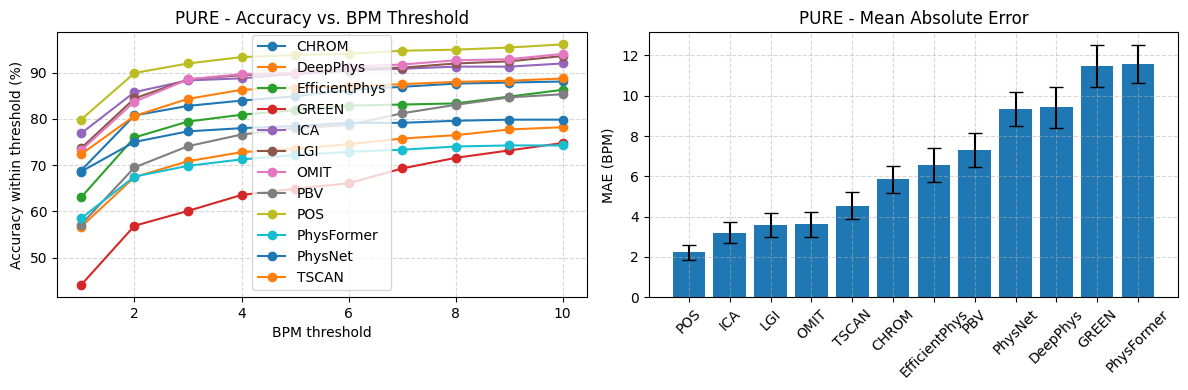

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ----------------------------
# 1) Point these to your files
# ----------------------------
# Example: map method name -> CSV path
method_files = {
    "CHROM": "/zfsauton/data/straps/PURE/resultsFineFFT/CHROM_PURE/raw_predictions_per_window.csv",
    "GREEN": "/zfsauton/data/straps/PURE/resultsFineFFT/GREEN_PURE/raw_predictions_per_window.csv",
    "ICA": "/zfsauton/data/straps/PURE/resultsFineFFT/ICA_PURE/raw_predictions_per_window.csv",
    "LGI": "/zfsauton/data/straps/PURE/resultsFineFFT/LGI_PURE/raw_predictions_per_window.csv",
    "OMIT": "/zfsauton/data/straps/PURE/resultsFineFFT/OMIT_PURE/raw_predictions_per_window.csv",
    "PBV": "/zfsauton/data/straps/PURE/resultsFineFFT/PBV_PURE/raw_predictions_per_window.csv",
    "POS": "/zfsauton/data/straps/PURE/resultsFineFFT/POS_PURE/raw_predictions_per_window.csv",
    "TSCAN": "/zfsauton/data/straps/PURE/resultsFineFFT/UBFC-rPPG_TSCAN_PURE/predictions_per_window.csv",
    "DeepPhys": "/zfsauton/data/straps/PURE/resultsFineFFT/UBFC-rPPG_DeepPhys_PURE/predictions_per_window.csv",
    "EfficientPhys": "/zfsauton/data/straps/PURE/resultsFineFFT/UBFC-rPPG_EfficientPhys_PURE/predictions_per_window.csv",
    "PhysFormer": "/zfsauton/data/straps/PURE/resultsFineFFT/UBFC-rPPG_PhysFormer_DiffNormalized_PURE/predictions_per_window.csv",
    "PhysNet": "/zfsauton/data/straps/PURE/resultsFineFFT/UBFC-rPPG_PhysNet_DiffNormalized_PURE/predictions_per_window.csv"
}

# If your CSVs are tab-separated (like your excerpt), leave sep=None (auto-infer) with engine="python"
read_kwargs = dict(sep=None, engine="python")  # change to sep="," if strictly comma-separated

# ---------------------------------------------
# 2) Helper: load and standardize one CSV frame
# ---------------------------------------------
def load_results(method_name, path):
    df = pd.read_csv(path, **read_kwargs)
    # Normalize likely column names (edit here if yours differ)
    # Expected columns: predicted_hr, ground_truth_hr
    # If yours are named differently, adjust the mapping below.
    rename_map = {
        "predicted_hr": "predicted_hr",
        "ground_truth_hr": "ground_truth_hr",
        "participant_id": "participant_id",
        "window_index": "window_index",
    }
    # only rename columns that actually exist
    rename_map = {k: v for k, v in rename_map.items() if k in df.columns}
    df = df.rename(columns=rename_map)

    # Basic checks
    required = {"predicted_hr", "ground_truth_hr"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{method_name}: Missing columns {missing} in {path}")

    df["method"] = method_name
    df["abs_error"] = (df["predicted_hr"] - df["ground_truth_hr"]).abs()
    return df

# ----------------------------------------
# 3) Load all methods into a single table
# ----------------------------------------
frames = []
for m, p in method_files.items():
    if not Path(p).exists():
        raise FileNotFoundError(f"File not found for method '{m}': {p}")
    frames.append(load_results(m, p))

all_df = pd.concat(frames, ignore_index=True)

# ---------------------------------------------------
# 4) Compute accuracy curve for thresholds 1..10 bpm
# ---------------------------------------------------
thresholds = np.arange(1, 11)  # 1,2,...,10 bpm
rows = []
for method, g in all_df.groupby("method"):
    for t in thresholds:
        acc = (g["abs_error"] <= t).mean() * 100.0  # percentage
        rows.append({"method": method, "threshold_bpm": t, "accuracy_pct": acc})

acc_curve = pd.DataFrame(rows)

# ---------------------------------------------------
# 5) Compute MAE and MAPE for each method
# ---------------------------------------------------
mae_mape_rows = []
for method, g in all_df.groupby("method"):
    predictions = g["predicted_hr"].values
    ground_truth = g["ground_truth_hr"].values
    num_samples = len(predictions)
    
    # MAE calculation
    mae = np.mean(np.abs(predictions - ground_truth))
    mae_std_error = np.std(np.abs(predictions - ground_truth)) / np.sqrt(num_samples)
    
    # MAPE calculation
    mape = np.mean(np.abs((predictions - ground_truth) / ground_truth)) * 100
    mape_std_error = np.std(np.abs((predictions - ground_truth) / ground_truth)) / np.sqrt(num_samples) * 100
    
    mae_mape_rows.append({
        "method": method,
        "MAE": mae,
        "MAE_SE": mae_std_error,
        "MAPE": mape,
        "MAPE_SE": mape_std_error
    })

mae_mape_df = pd.DataFrame(mae_mape_rows).set_index("method").sort_index()

# -------------------------------------------------------------
# 6) Print the headline accuracy numbers (1, 3, 5, and 10 bpm)
# -------------------------------------------------------------
headline_ts = [1, 3, 5, 10]
headline_acc = (
    acc_curve[acc_curve["threshold_bpm"].isin(headline_ts)]
    .pivot(index="method", columns="threshold_bpm", values="accuracy_pct")
    .rename(columns={1: "acc_1bpm(%)", 3: "acc_3bpm(%)", 5: "acc_5bpm(%)", 10: "acc_10bpm(%)"})
    .sort_index()
)

print("=== ACCURACY WITHIN THRESHOLDS ===")
print(headline_acc.round(2))
print()

print("=== MAE AND MAPE METRICS ===")
print(mae_mape_df.round(3))
print()

# Optional: Combined summary table
print("=== COMBINED SUMMARY ===")
combined_summary = pd.concat([
    headline_acc[["acc_5bpm(%)"]],  # Just 5 BPM accuracy for brevity
    mae_mape_df[["MAE", "MAPE"]]    # MAE and MAPE
], axis=1).round(3)
print(combined_summary)

# ------------------------------------------------
# 7) Plot: accuracy vs bpm threshold (per method)
# ------------------------------------------------
plt.figure(figsize=(12, 4))

# Plot 1: Accuracy curves
plt.subplot(1, 2, 1)
for method, g in acc_curve.groupby("method"):
    g = g.sort_values("threshold_bpm")
    plt.plot(g["threshold_bpm"], g["accuracy_pct"], marker="o", label=method)

plt.xlabel("BPM threshold")
plt.ylabel("Accuracy within threshold (%)")
plt.title("PURE - Accuracy vs. BPM Threshold")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

# Plot 2: MAE comparison
plt.subplot(1, 2, 2)
mae_mape_sorted = mae_mape_df.sort_values("MAE")
plt.bar(range(len(mae_mape_sorted)), mae_mape_sorted["MAE"], 
        yerr=mae_mape_sorted["MAE_SE"], capsize=5)
plt.xticks(range(len(mae_mape_sorted)), mae_mape_sorted.index, rotation=45)
plt.ylabel("MAE (BPM)")
plt.title("PURE - Mean Absolute Error")
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

=== ACCURACY WITHIN THRESHOLDS ===
threshold_bpm  acc_1bpm(%)  acc_3bpm(%)  acc_5bpm(%)  acc_10bpm(%)
method                                                            
CHROM                84.81        92.58        92.58         95.41
DeepPhys             92.83        97.13        97.49         99.28
EfficientPhys        91.04        95.70        96.42         97.13
GREEN                62.90        69.26        69.26         72.79
ICA                  67.49        76.33        77.39         78.45
LGI                  79.15        84.81        85.16         86.93
OMIT                 79.15        85.16        85.51         87.28
PBV                  68.90        77.03        77.39         79.86
POS                  89.05        94.70        95.05         98.23
PhysFormer           91.81        97.51        99.29         99.64
PhysNet              73.85        85.51        87.99         92.23
TSCAN                94.62        98.21        98.57         99.28

=== MAE, RMSE, AND MAPE ME

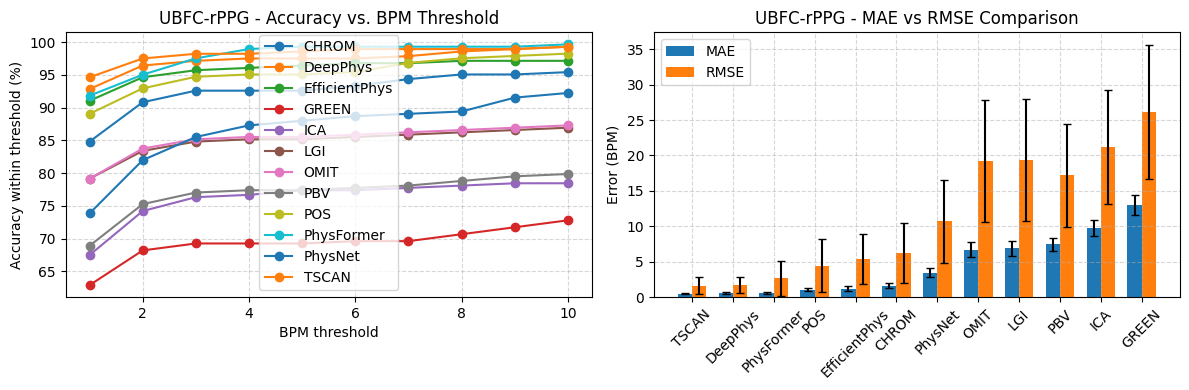

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ----------------------------
# 1) Point these to your files
# ----------------------------
# Example: map method name -> CSV path
method_files = {
    "CHROM": "/zfsauton/data/straps/UBFC-rPPG/resultsFineFFT/CHROM_UBFC-rPPG/raw_predictions_per_window.csv",
    "GREEN": "/zfsauton/data/straps/UBFC-rPPG/resultsFineFFT/GREEN_UBFC-rPPG/raw_predictions_per_window.csv",
    "ICA": "/zfsauton/data/straps/UBFC-rPPG/resultsFineFFT/ICA_UBFC-rPPG/raw_predictions_per_window.csv",
    "LGI": "/zfsauton/data/straps/UBFC-rPPG/resultsFineFFT/LGI_UBFC-rPPG/raw_predictions_per_window.csv",
    "OMIT": "/zfsauton/data/straps/UBFC-rPPG/resultsFineFFT/OMIT_UBFC-rPPG/raw_predictions_per_window.csv",
    "PBV": "/zfsauton/data/straps/UBFC-rPPG/resultsFineFFT/PBV_UBFC-rPPG/raw_predictions_per_window.csv",
    "POS": "/zfsauton/data/straps/UBFC-rPPG/resultsFineFFT/POS_UBFC-rPPG/raw_predictions_per_window.csv",
    "TSCAN": "/zfsauton/data/straps/UBFC-rPPG/resultsFineFFT/PURE_TSCAN_UBFC-rPPG/predictions_per_window.csv",
    "DeepPhys": "/zfsauton/data/straps/UBFC-rPPG/resultsFineFFT/PURE_DeepPhys_UBFC-rPPG/predictions_per_window.csv",
    "EfficientPhys": "/zfsauton/data/straps/UBFC-rPPG/resultsFineFFT/PURE_EfficientPhys_UBFC-rPPG/predictions_per_window.csv",
    "PhysFormer": "/zfsauton/data/straps/UBFC-rPPG/resultsFineFFT/PURE_PhysFormer_DiffNormalized_UBFC-rPPG/predictions_per_window.csv",
    "PhysNet": "/zfsauton/data/straps/UBFC-rPPG/resultsFineFFT/PURE_PhysNet_DiffNormalized_UBFC-rPPG/predictions_per_window.csv"
}

# If your CSVs are tab-separated (like your excerpt), leave sep=None (auto-infer) with engine="python"
read_kwargs = dict(sep=None, engine="python")  # change to sep="," if strictly comma-separated

# ---------------------------------------------
# 2) Helper: load and standardize one CSV frame
# ---------------------------------------------
def load_results(method_name, path):
    df = pd.read_csv(path, **read_kwargs)
    # Normalize likely column names (edit here if yours differ)
    # Expected columns: predicted_hr, ground_truth_hr
    # If yours are named differently, adjust the mapping below.
    rename_map = {
        "predicted_hr": "predicted_hr",
        "ground_truth_hr": "ground_truth_hr",
        "participant_id": "participant_id",
        "window_index": "window_index",
    }
    # only rename columns that actually exist
    rename_map = {k: v for k, v in rename_map.items() if k in df.columns}
    df = df.rename(columns=rename_map)

    # Basic checks
    required = {"predicted_hr", "ground_truth_hr"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{method_name}: Missing columns {missing} in {path}")

    df["method"] = method_name
    df["abs_error"] = (df["predicted_hr"] - df["ground_truth_hr"]).abs()
    return df

# ----------------------------------------
# 3) Load all methods into a single table
# ----------------------------------------
frames = []
for m, p in method_files.items():
    if not Path(p).exists():
        raise FileNotFoundError(f"File not found for method '{m}': {p}")
    frames.append(load_results(m, p))

all_df = pd.concat(frames, ignore_index=True)

# ---------------------------------------------------
# 4) Compute accuracy curve for thresholds 1..10 bpm
# ---------------------------------------------------
thresholds = np.arange(1, 11)  # 1,2,...,10 bpm
rows = []
for method, g in all_df.groupby("method"):
    for t in thresholds:
        acc = (g["abs_error"] <= t).mean() * 100.0  # percentage
        rows.append({"method": method, "threshold_bpm": t, "accuracy_pct": acc})

acc_curve = pd.DataFrame(rows)

# ---------------------------------------------------
# 5) Compute MAE, RMSE, and MAPE for each method
# ---------------------------------------------------
metrics_rows = []
for method, g in all_df.groupby("method"):
    predictions = g["predicted_hr"].values
    ground_truth = g["ground_truth_hr"].values
    num_samples = len(predictions)
    
    # MAE calculation
    mae = np.mean(np.abs(predictions - ground_truth))
    mae_std_error = np.std(np.abs(predictions - ground_truth)) / np.sqrt(num_samples)
    
    # RMSE calculation
    squared_errors = np.square(predictions - ground_truth)
    rmse = np.sqrt(np.mean(squared_errors))
    rmse_std_error = np.sqrt(np.std(squared_errors) / np.sqrt(num_samples))
    
    # MAPE calculation
    mape = np.mean(np.abs((predictions - ground_truth) / ground_truth)) * 100
    mape_std_error = np.std(np.abs((predictions - ground_truth) / ground_truth)) / np.sqrt(num_samples) * 100
    
    metrics_rows.append({
        "method": method,
        "MAE": mae,
        "MAE_SE": mae_std_error,
        "RMSE": rmse,
        "RMSE_SE": rmse_std_error,
        "MAPE": mape,
        "MAPE_SE": mape_std_error
    })

metrics_df = pd.DataFrame(metrics_rows).set_index("method").sort_index()

# -------------------------------------------------------------
# 6) Print the headline accuracy numbers (1, 3, 5, and 10 bpm)
# -------------------------------------------------------------
headline_ts = [1, 3, 5, 10]
headline_acc = (
    acc_curve[acc_curve["threshold_bpm"].isin(headline_ts)]
    .pivot(index="method", columns="threshold_bpm", values="accuracy_pct")
    .rename(columns={1: "acc_1bpm(%)", 3: "acc_3bpm(%)", 5: "acc_5bpm(%)", 10: "acc_10bpm(%)"})
    .sort_index()
)

print("=== ACCURACY WITHIN THRESHOLDS ===")
print(headline_acc.round(2))
print()

print("=== MAE, RMSE, AND MAPE METRICS ===")
print(metrics_df.round(3))
print()

# Optional: Combined summary table
print("=== COMBINED SUMMARY ===")
combined_summary = pd.concat([
    headline_acc[["acc_5bpm(%)"]],  # Just 5 BPM accuracy for brevity
    metrics_df[["MAE", "RMSE", "MAPE"]]    # MAE, RMSE, and MAPE
], axis=1).round(3)
print(combined_summary)

# ------------------------------------------------
# 7) Plot: accuracy vs bpm threshold (per method)
# ------------------------------------------------
plt.figure(figsize=(12, 4))

# Plot 1: Accuracy curves
plt.subplot(1, 2, 1)
for method, g in acc_curve.groupby("method"):
    g = g.sort_values("threshold_bpm")
    plt.plot(g["threshold_bpm"], g["accuracy_pct"], marker="o", label=method)

plt.xlabel("BPM threshold")
plt.ylabel("Accuracy within threshold (%)")
plt.title("UBFC-rPPG - Accuracy vs. BPM Threshold")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

# Plot 2: Error metrics comparison
plt.subplot(1, 2, 2)
metrics_sorted = metrics_df.sort_values("MAE")
x_pos = np.arange(len(metrics_sorted))

# Create grouped bar chart for MAE and RMSE
width = 0.35
plt.bar(x_pos - width/2, metrics_sorted["MAE"], width, 
        yerr=metrics_sorted["MAE_SE"], capsize=3, label='MAE')
plt.bar(x_pos + width/2, metrics_sorted["RMSE"], width,
        yerr=metrics_sorted["RMSE_SE"], capsize=3, label='RMSE')

plt.xticks(x_pos, metrics_sorted.index, rotation=45)
plt.ylabel("Error (BPM)")
plt.title("UBFC-rPPG - MAE vs RMSE Comparison")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

=== ACCURACY WITHIN THRESHOLDS ===
threshold_bpm  acc_1bpm(%)  acc_3bpm(%)  acc_5bpm(%)  acc_10bpm(%)
method                                                            
CHROM                68.81        82.80        84.86         88.07
DeepPhys             56.62        70.83        73.53         78.19
EfficientPhys        62.99        79.41        81.86         86.27
GREEN                44.04        60.09        64.91         74.77
ICA                  76.83        88.30        89.68         91.97
LGI                  73.62        88.53        89.91         93.58
OMIT                 73.17        88.53        89.91         94.04
PBV                  57.11        74.08        77.98         85.32
POS                  79.82        91.97        93.81         96.10
PhysFormer           58.47        69.84        72.16         74.25
PhysNet              68.58        77.29        78.44         79.82
TSCAN                72.30        84.31        86.76         88.73

=== MAE, RMSE, AND MAPE ME

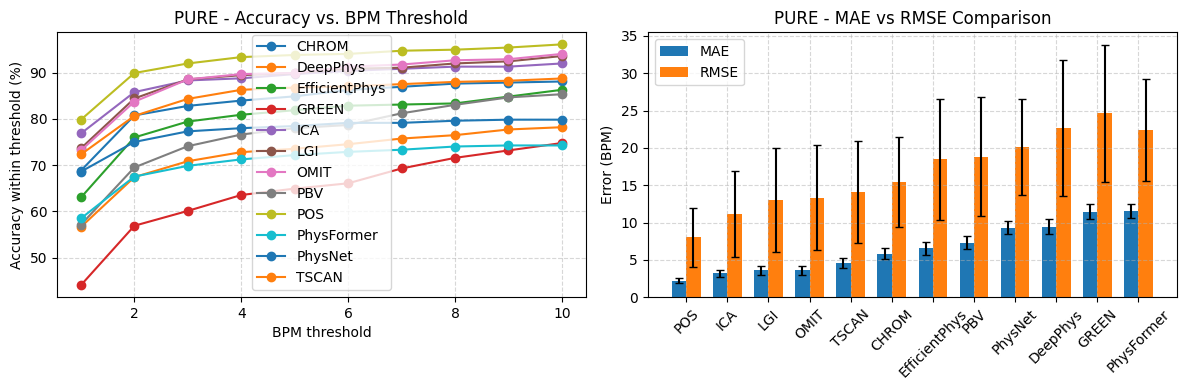

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ----------------------------
# 1) Point these to your files
# ----------------------------
method_files = {
    "CHROM": "/zfsauton/data/straps/PURE/resultsFineFFT/CHROM_PURE/raw_predictions_per_window.csv",
    "GREEN": "/zfsauton/data/straps/PURE/resultsFineFFT/GREEN_PURE/raw_predictions_per_window.csv",
    "ICA": "/zfsauton/data/straps/PURE/resultsFineFFT/ICA_PURE/raw_predictions_per_window.csv",
    "LGI": "/zfsauton/data/straps/PURE/resultsFineFFT/LGI_PURE/raw_predictions_per_window.csv",
    "OMIT": "/zfsauton/data/straps/PURE/resultsFineFFT/OMIT_PURE/raw_predictions_per_window.csv",
    "PBV": "/zfsauton/data/straps/PURE/resultsFineFFT/PBV_PURE/raw_predictions_per_window.csv",
    "POS": "/zfsauton/data/straps/PURE/resultsFineFFT/POS_PURE/raw_predictions_per_window.csv",
    "TSCAN": "/zfsauton/data/straps/PURE/resultsFineFFT/UBFC-rPPG_TSCAN_PURE/predictions_per_window.csv",
    "DeepPhys": "/zfsauton/data/straps/PURE/resultsFineFFT/UBFC-rPPG_DeepPhys_PURE/predictions_per_window.csv",
    "EfficientPhys": "/zfsauton/data/straps/PURE/resultsFineFFT/UBFC-rPPG_EfficientPhys_PURE/predictions_per_window.csv",
    "PhysFormer": "/zfsauton/data/straps/PURE/resultsFineFFT/UBFC-rPPG_PhysFormer_DiffNormalized_PURE/predictions_per_window.csv",
    "PhysNet": "/zfsauton/data/straps/PURE/resultsFineFFT/UBFC-rPPG_PhysNet_DiffNormalized_PURE/predictions_per_window.csv"
}
# If your CSVs are tab-separated (like your excerpt), leave sep=None (auto-infer) with engine="python"
read_kwargs = dict(sep=None, engine="python")  # change to sep="," if strictly comma-separated

# ---------------------------------------------
# 2) Helper: load and standardize one CSV frame
# ---------------------------------------------
def load_results(method_name, path):
    df = pd.read_csv(path, **read_kwargs)
    # Normalize likely column names (edit here if yours differ)
    # Expected columns: predicted_hr, ground_truth_hr
    # If yours are named differently, adjust the mapping below.
    rename_map = {
        "predicted_hr": "predicted_hr",
        "ground_truth_hr": "ground_truth_hr",
        "participant_id": "participant_id",
        "window_index": "window_index",
    }
    # only rename columns that actually exist
    rename_map = {k: v for k, v in rename_map.items() if k in df.columns}
    df = df.rename(columns=rename_map)

    # Basic checks
    required = {"predicted_hr", "ground_truth_hr"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{method_name}: Missing columns {missing} in {path}")

    df["method"] = method_name
    df["abs_error"] = (df["predicted_hr"] - df["ground_truth_hr"]).abs()
    return df

# ----------------------------------------
# 3) Load all methods into a single table
# ----------------------------------------
frames = []
for m, p in method_files.items():
    if not Path(p).exists():
        raise FileNotFoundError(f"File not found for method '{m}': {p}")
    frames.append(load_results(m, p))

all_df = pd.concat(frames, ignore_index=True)

# ---------------------------------------------------
# 4) Compute accuracy curve for thresholds 1..10 bpm
# ---------------------------------------------------
thresholds = np.arange(1, 11)  # 1,2,...,10 bpm
rows = []
for method, g in all_df.groupby("method"):
    for t in thresholds:
        acc = (g["abs_error"] <= t).mean() * 100.0  # percentage
        rows.append({"method": method, "threshold_bpm": t, "accuracy_pct": acc})

acc_curve = pd.DataFrame(rows)

# ---------------------------------------------------
# 5) Compute MAE, RMSE, and MAPE for each method
# ---------------------------------------------------
metrics_rows = []
for method, g in all_df.groupby("method"):
    predictions = g["predicted_hr"].values
    ground_truth = g["ground_truth_hr"].values
    num_samples = len(predictions)
    
    # MAE calculation
    mae = np.mean(np.abs(predictions - ground_truth))
    mae_std_error = np.std(np.abs(predictions - ground_truth)) / np.sqrt(num_samples)
    
    # RMSE calculation
    squared_errors = np.square(predictions - ground_truth)
    rmse = np.sqrt(np.mean(squared_errors))
    rmse_std_error = np.sqrt(np.std(squared_errors) / np.sqrt(num_samples))
    
    # MAPE calculation
    mape = np.mean(np.abs((predictions - ground_truth) / ground_truth)) * 100
    mape_std_error = np.std(np.abs((predictions - ground_truth) / ground_truth)) / np.sqrt(num_samples) * 100
    
    metrics_rows.append({
        "method": method,
        "MAE": mae,
        "MAE_SE": mae_std_error,
        "RMSE": rmse,
        "RMSE_SE": rmse_std_error,
        "MAPE": mape,
        "MAPE_SE": mape_std_error
    })

metrics_df = pd.DataFrame(metrics_rows).set_index("method").sort_index()

# -------------------------------------------------------------
# 6) Print the headline accuracy numbers (1, 3, 5, and 10 bpm)
# -------------------------------------------------------------
headline_ts = [1, 3, 5, 10]
headline_acc = (
    acc_curve[acc_curve["threshold_bpm"].isin(headline_ts)]
    .pivot(index="method", columns="threshold_bpm", values="accuracy_pct")
    .rename(columns={1: "acc_1bpm(%)", 3: "acc_3bpm(%)", 5: "acc_5bpm(%)", 10: "acc_10bpm(%)"})
    .sort_index()
)

print("=== ACCURACY WITHIN THRESHOLDS ===")
print(headline_acc.round(2))
print()

print("=== MAE, RMSE, AND MAPE METRICS ===")
print(metrics_df.round(3))
print()

# Optional: Combined summary table
print("=== COMBINED SUMMARY ===")
combined_summary = pd.concat([
    headline_acc[["acc_5bpm(%)"]],  # Just 5 BPM accuracy for brevity
    metrics_df[["MAE", "RMSE", "MAPE"]]    # MAE, RMSE, and MAPE
], axis=1).round(3)
print(combined_summary)

# ------------------------------------------------
# 7) Plot: accuracy vs bpm threshold (per method)
# ------------------------------------------------
plt.figure(figsize=(12, 4))

# Plot 1: Accuracy curves
plt.subplot(1, 2, 1)
for method, g in acc_curve.groupby("method"):
    g = g.sort_values("threshold_bpm")
    plt.plot(g["threshold_bpm"], g["accuracy_pct"], marker="o", label=method)

plt.xlabel("BPM threshold")
plt.ylabel("Accuracy within threshold (%)")
plt.title("PURE - Accuracy vs. BPM Threshold")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

# Plot 2: Error metrics comparison
plt.subplot(1, 2, 2)
metrics_sorted = metrics_df.sort_values("MAE")
x_pos = np.arange(len(metrics_sorted))

# Create grouped bar chart for MAE and RMSE
width = 0.35
plt.bar(x_pos - width/2, metrics_sorted["MAE"], width, 
        yerr=metrics_sorted["MAE_SE"], capsize=3, label='MAE')
plt.bar(x_pos + width/2, metrics_sorted["RMSE"], width,
        yerr=metrics_sorted["RMSE_SE"], capsize=3, label='RMSE')

plt.xticks(x_pos, metrics_sorted.index, rotation=45)
plt.ylabel("Error (BPM)")
plt.title("PURE - MAE vs RMSE Comparison")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

PRISM data shape: (42, 3)
TSCAN data shape: (42, 2)

Number of matched participants: 42

=== PAIRED T-TEST RESULTS: PRISM vs TSCAN (MAE) ===
Number of paired samples: 42

Descriptive Statistics:
PRISM MAE - Mean: 0.6650, SD: 0.5453
TSCAN MAE - Mean: 0.5139, SD: 0.5415

Difference Statistics (PRISM - TSCAN):
Mean difference: 0.1510
Standard deviation of differences: 0.7547
95% CI for mean difference: [-0.0842, 0.3862]

Statistical Test Results:
t-statistic: 1.2814
p-value: 0.207257
Cohen's d (effect size): 0.2001

Effect Size Interpretation:
Effect size is small (|Cohen's d| = 0.200)

Interpretation:
Result is not significant (p ≥ 0.05)
TSCAN has significantly lower MAE (better performance)

=== INDIVIDUAL PARTICIPANT COMPARISONS ===
PRISM performs better on 10/42 participants (23.8%)
TSCAN performs better on 32/42 participants (76.2%)

Participants with largest differences:
Top 5 largest absolute differences:
1. subject12: PRISM=0.361, TSCAN=2.684, diff=-2.323 (PRISM better)
2. subject

/tmp/ipykernel_172403/1713736736.py:191: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([prism_mae, tscan_mae], labels=['PRISM', 'TSCAN'])


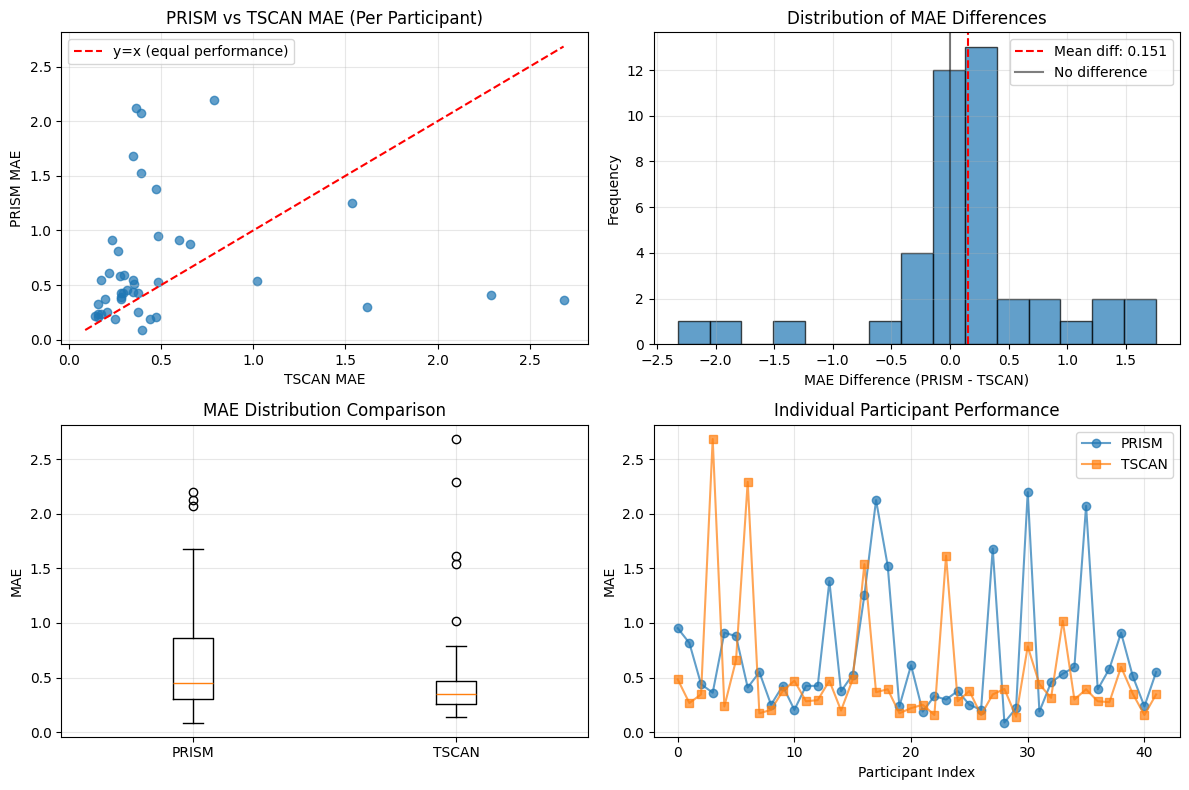


=== SUMMARY ===
Statistical significance: not significant (p ≥ 0.05)
Effect size: small (Cohen's d = 0.200)
Mean difference: 0.1510 ± 0.1165
Better method: TSCAN


In [16]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_rel
import matplotlib.pyplot as plt

# PRISM data
prism_data = {
    'name': ['subject1', 'subject10', 'subject11', 'subject12', 'subject13', 'subject14', 
             'subject15', 'subject16', 'subject17', 'subject18', 'subject20', 'subject22',
             'subject23', 'subject24', 'subject25', 'subject26', 'subject27', 'subject3',
             'subject30', 'subject31', 'subject32', 'subject33', 'subject34', 'subject35',
             'subject36', 'subject37', 'subject38', 'subject39', 'subject4', 'subject40',
             'subject41', 'subject42', 'subject43', 'subject44', 'subject45', 'subject46',
             'subject47', 'subject48', 'subject49', 'subject5', 'subject8', 'subject9'],
    'mae_ours': [0.9521484375, 0.8161272321, 0.439453125, 0.3609793527, 0.9102957589, 0.87890625,
                 0.4080636161, 0.5493164063, 0.2511160714, 0.4237583705, 0.204031808, 0.4237583705,
                 0.4237583705, 1.381138393, 0.3735351563, 0.52734375, 1.252441406, 2.124023438,
                 1.522391183, 0.235421317, 0.6120954241, 0.1883370536, 0.3295898438, 0.2982003348,
                 0.3766741071, 0.2511160714, 0.204031808, 1.679338728, 0.087890625, 0.2197265625,
                 2.197265625, 0.1883370536, 0.4551478795, 0.5336216518, 0.5964006696, 2.071707589,
                 0.3923688616, 0.5807059152, 0.9102957589, 0.5126953125, 0.235421317, 0.5493164063],
    'rmse_ours': [1.173018851, 1.206354002, 0.5350046908, 0.5034568024, 1.465758991, 1.023894795,
                  0.5153044658, 0.7622869699, 0.3107402847, 0.4895656586, 0.2456617651, 0.5398174236,
                  0.523602978, 2.971245427, 0.4888607401, 0.9032873199, 1.513563583, 4.236033323,
                  2.999833801, 0.2658860022, 1.012889406, 0.2626234737, 0.4214268075, 0.3347805543,
                  0.4697951518, 0.3162405398, 0.2311981703, 3.296160006, 0.1203491948, 0.2491465032,
                  3.739042622, 0.2559736989, 0.6173048408, 0.7144130866, 0.76115514, 4.472702131,
                  0.4642570979, 0.703468239, 1.030608932, 0.9125929537, 0.2965436535, 0.9514439251]
}

# TSCAN data
tscan_data = {
    'participant_id': ['subject1', 'subject10', 'subject11', 'subject12', 'subject13', 'subject14',
                       'subject15', 'subject16', 'subject17', 'subject18', 'subject20', 'subject22',
                       'subject23', 'subject24', 'subject25', 'subject26', 'subject27', 'subject3',
                       'subject30', 'subject31', 'subject32', 'subject33', 'subject34', 'subject35',
                       'subject36', 'subject37', 'subject38', 'subject39', 'subject4', 'subject40',
                       'subject41', 'subject42', 'subject43', 'subject44', 'subject45', 'subject46',
                       'subject47', 'subject48', 'subject49', 'subject5', 'subject8', 'subject9'],
    'MAE': [0.4833984375, 0.266810825892857, 0.345284598214286, 2.68380301339286, 0.235421316964286, 0.6591796875,
            2.29143415178571, 0.172642299107143, 0.204031808035714, 0.376674107142857, 0.470842633928571, 0.282505580357143,
            0.29296875, 0.470842633928571, 0.19775390625, 0.4833984375, 1.5380859375, 0.3662109375,
            0.392368861607143, 0.172642299107143, 0.2197265625, 0.251116071428571, 0.156947544642857, 1.61655970982143,
            0.282505580357143, 0.376674107142857, 0.156947544642857, 0.345284598214286, 0.3955078125, 0.141252790178571,
            0.784737723214286, 0.439453125, 0.313895089285714, 1.02015904017857, 0.298200334821429, 0.392368861607143,
            0.282505580357143, 0.274658203125, 0.596400669642857, 0.3515625, 0.156947544642857, 0.345284598214286]
}

# Create DataFrames
prism_df = pd.DataFrame(prism_data)
tscan_df = pd.DataFrame(tscan_data)

print("PRISM data shape:", prism_df.shape)
print("TSCAN data shape:", tscan_df.shape)
print()

# Merge on participant ID
merged_df = pd.merge(prism_df, tscan_df, left_on='name', right_on='participant_id', how='inner')
print(f"Number of matched participants: {len(merged_df)}")
print()

# Extract paired values
prism_mae = merged_df['mae_ours'].values
tscan_mae = merged_df['MAE'].values

# Perform paired t-test
t_stat, p_value = ttest_rel(prism_mae, tscan_mae)

# Calculate descriptive statistics
prism_mean = np.mean(prism_mae)
tscan_mean = np.mean(tscan_mae)
prism_std = np.std(prism_mae)
tscan_std = np.std(tscan_mae)

# Calculate difference statistics
differences = prism_mae - tscan_mae
mean_diff = np.mean(differences)
std_diff = np.std(differences)

# Calculate effect size (Cohen's d for paired samples)
cohens_d = mean_diff / std_diff

# Calculate 95% confidence interval for the mean difference
from scipy import stats
se_diff = std_diff / np.sqrt(len(differences))
ci_lower, ci_upper = stats.t.interval(0.95, len(differences)-1, mean_diff, se_diff)

print("=== PAIRED T-TEST RESULTS: PRISM vs TSCAN (MAE) ===")
print(f"Number of paired samples: {len(prism_mae)}")
print()

print("Descriptive Statistics:")
print(f"PRISM MAE - Mean: {prism_mean:.4f}, SD: {prism_std:.4f}")
print(f"TSCAN MAE - Mean: {tscan_mean:.4f}, SD: {tscan_std:.4f}")
print()

print("Difference Statistics (PRISM - TSCAN):")
print(f"Mean difference: {mean_diff:.4f}")
print(f"Standard deviation of differences: {std_diff:.4f}")
print(f"95% CI for mean difference: [{ci_lower:.4f}, {ci_upper:.4f}]")
print()

print("Statistical Test Results:")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.6f}")
print(f"Cohen's d (effect size): {cohens_d:.4f}")
print()

print("Effect Size Interpretation:")
if abs(cohens_d) < 0.2:
    effect_size = "negligible"
elif abs(cohens_d) < 0.5:
    effect_size = "small"
elif abs(cohens_d) < 0.8:
    effect_size = "medium"
else:
    effect_size = "large"
print(f"Effect size is {effect_size} (|Cohen's d| = {abs(cohens_d):.3f})")
print()

print("Interpretation:")
if p_value < 0.001:
    significance = "highly significant (p < 0.001)"
elif p_value < 0.01:
    significance = "very significant (p < 0.01)"
elif p_value < 0.05:
    significance = "significant (p < 0.05)"
else:
    significance = "not significant (p ≥ 0.05)"

if mean_diff < 0:
    better_method = "PRISM has significantly lower MAE (better performance)"
elif mean_diff > 0:
    better_method = "TSCAN has significantly lower MAE (better performance)"
else:
    better_method = "No difference in performance"

print(f"Result is {significance}")
print(f"{better_method}")
print()

# Individual participant comparison
print("=== INDIVIDUAL PARTICIPANT COMPARISONS ===")
merged_comparison = merged_df[['name', 'mae_ours', 'MAE']].copy()
merged_comparison['difference'] = merged_comparison['mae_ours'] - merged_comparison['MAE']
merged_comparison['prism_better'] = merged_comparison['difference'] < 0

prism_wins = merged_comparison['prism_better'].sum()
tscan_wins = (~merged_comparison['prism_better']).sum()

print(f"PRISM performs better on {prism_wins}/{len(merged_comparison)} participants ({prism_wins/len(merged_comparison)*100:.1f}%)")
print(f"TSCAN performs better on {tscan_wins}/{len(merged_comparison)} participants ({tscan_wins/len(merged_comparison)*100:.1f}%)")
print()

# Show participants where difference is largest
print("Participants with largest differences:")
merged_comparison_sorted = merged_comparison.reindex(merged_comparison['difference'].abs().sort_values(ascending=False).index)
print("Top 5 largest absolute differences:")
for i, (_, row) in enumerate(merged_comparison_sorted.head(5).iterrows()):
    better = "PRISM" if row['difference'] < 0 else "TSCAN"
    print(f"{i+1}. {row['name']}: PRISM={row['mae_ours']:.3f}, TSCAN={row['MAE']:.3f}, diff={row['difference']:.3f} ({better} better)")

# Visualization
plt.figure(figsize=(12, 8))

# Plot 1: Paired comparison
plt.subplot(2, 2, 1)
plt.scatter(tscan_mae, prism_mae, alpha=0.7)
plt.plot([min(tscan_mae.min(), prism_mae.min()), max(tscan_mae.max(), prism_mae.max())], 
         [min(tscan_mae.min(), prism_mae.min()), max(tscan_mae.max(), prism_mae.max())], 
         'r--', label='y=x (equal performance)')
plt.xlabel('TSCAN MAE')
plt.ylabel('PRISM MAE')
plt.title('PRISM vs TSCAN MAE (Per Participant)')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Distribution of differences
plt.subplot(2, 2, 2)
plt.hist(differences, bins=15, edgecolor='black', alpha=0.7)
plt.axvline(mean_diff, color='red', linestyle='--', label=f'Mean diff: {mean_diff:.3f}')
plt.axvline(0, color='black', linestyle='-', alpha=0.5, label='No difference')
plt.xlabel('MAE Difference (PRISM - TSCAN)')
plt.ylabel('Frequency')
plt.title('Distribution of MAE Differences')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 3: Box plot comparison
plt.subplot(2, 2, 3)
plt.boxplot([prism_mae, tscan_mae], labels=['PRISM', 'TSCAN'])
plt.ylabel('MAE')
plt.title('MAE Distribution Comparison')
plt.grid(True, alpha=0.3)

# Plot 4: Individual participant comparison
plt.subplot(2, 2, 4)
participants = range(len(prism_mae))
plt.plot(participants, prism_mae, 'o-', label='PRISM', alpha=0.7)
plt.plot(participants, tscan_mae, 's-', label='TSCAN', alpha=0.7)
plt.xlabel('Participant Index')
plt.ylabel('MAE')
plt.title('Individual Participant Performance')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== SUMMARY ===")
print(f"Statistical significance: {significance}")
print(f"Effect size: {effect_size} (Cohen's d = {cohens_d:.3f})")
print(f"Mean difference: {mean_diff:.4f} ± {se_diff:.4f}")
print(f"Better method: {'PRISM' if mean_diff < 0 else 'TSCAN' if mean_diff > 0 else 'Tie'}")



Data shapes:
PRISM: (42, 2)
TSCAN: (42, 2)
PhysFormer: (42, 2)

Number of matched participants across all methods: 42

MULTIPLE PAIRWISE COMPARISONS

=== PAIRED T-TEST: PRISM vs TSCAN ===
Number of paired participants: 42

Descriptive Statistics:
PRISM MAE - Mean: 0.6650, SD: 0.5453
TSCAN MAE - Mean: 0.5139, SD: 0.5415

Difference Statistics (PRISM - TSCAN):
Mean difference: 0.1510
95% CI for mean difference: [-0.0842, 0.3862]

Statistical Test Results:
t-statistic: 1.2814
p-value: 0.207257
Cohen's d (effect size): 0.2001

Effect size: small (|Cohen's d| = 0.200)
Statistical significance: not significant (p ≥ 0.05)
Performance: TSCAN performs better (lower MAE)

Individual Participant Wins:
PRISM better: 10/42 (23.8%)
TSCAN better: 32/42 (76.2%)

=== PAIRED T-TEST: PRISM vs PhysFormer ===
Number of paired participants: 42

Descriptive Statistics:
PRISM MAE - Mean: 0.6650, SD: 0.5453
PhysFormer MAE - Mean: 0.6392, SD: 0.9143

Difference Statistics (PRISM - PhysFormer):
Mean difference: 

/tmp/ipykernel_172403/3740757148.py:262: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 0].boxplot(mae_values, labels=methods)


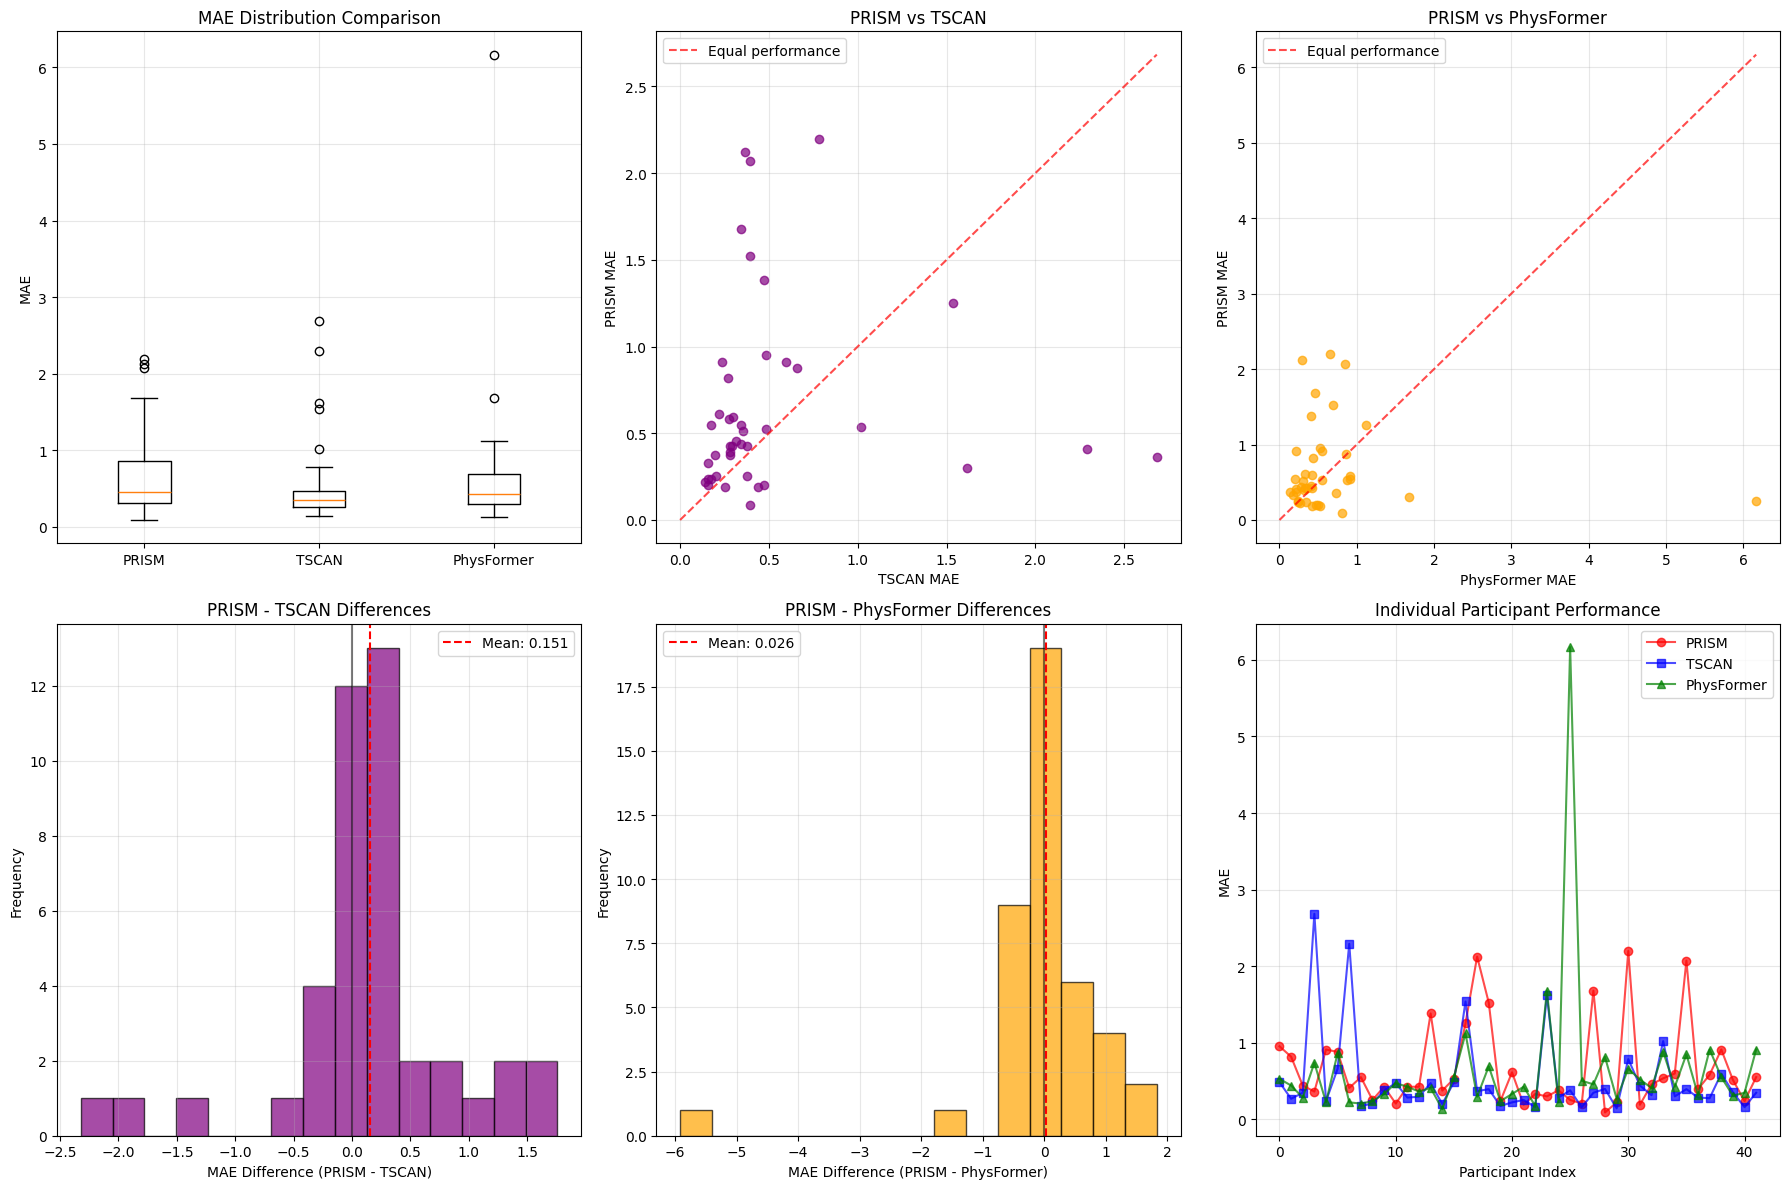

=== OVERALL CONCLUSIONS ===
PRISM mean MAE: 0.6650
TSCAN mean MAE: 0.5139
PhysFormer mean MAE: 0.6392

Methods ranked by performance (best to worst):
1. TSCAN: 0.5139
2. PhysFormer: 0.6392
3. PRISM: 0.6650


In [17]:

import pandas as pd
import numpy as np
from scipy.stats import ttest_rel
import matplotlib.pyplot as plt

# PRISM data
prism_data = {
    'name': ['subject1', 'subject10', 'subject11', 'subject12', 'subject13', 'subject14', 
             'subject15', 'subject16', 'subject17', 'subject18', 'subject20', 'subject22',
             'subject23', 'subject24', 'subject25', 'subject26', 'subject27', 'subject3',
             'subject30', 'subject31', 'subject32', 'subject33', 'subject34', 'subject35',
             'subject36', 'subject37', 'subject38', 'subject39', 'subject4', 'subject40',
             'subject41', 'subject42', 'subject43', 'subject44', 'subject45', 'subject46',
             'subject47', 'subject48', 'subject49', 'subject5', 'subject8', 'subject9'],
    'mae_ours': [0.9521484375, 0.8161272321, 0.439453125, 0.3609793527, 0.9102957589, 0.87890625,
                 0.4080636161, 0.5493164063, 0.2511160714, 0.4237583705, 0.204031808, 0.4237583705,
                 0.4237583705, 1.381138393, 0.3735351563, 0.52734375, 1.252441406, 2.124023438,
                 1.522391183, 0.235421317, 0.6120954241, 0.1883370536, 0.3295898438, 0.2982003348,
                 0.3766741071, 0.2511160714, 0.204031808, 1.679338728, 0.087890625, 0.2197265625,
                 2.197265625, 0.1883370536, 0.4551478795, 0.5336216518, 0.5964006696, 2.071707589,
                 0.3923688616, 0.5807059152, 0.9102957589, 0.5126953125, 0.235421317, 0.5493164063]
}

# TSCAN data
tscan_data = {
    'participant_id': ['subject1', 'subject10', 'subject11', 'subject12', 'subject13', 'subject14',
                       'subject15', 'subject16', 'subject17', 'subject18', 'subject20', 'subject22',
                       'subject23', 'subject24', 'subject25', 'subject26', 'subject27', 'subject3',
                       'subject30', 'subject31', 'subject32', 'subject33', 'subject34', 'subject35',
                       'subject36', 'subject37', 'subject38', 'subject39', 'subject4', 'subject40',
                       'subject41', 'subject42', 'subject43', 'subject44', 'subject45', 'subject46',
                       'subject47', 'subject48', 'subject49', 'subject5', 'subject8', 'subject9'],
    'MAE': [0.4833984375, 0.266810825892857, 0.345284598214286, 2.68380301339286, 0.235421316964286, 0.6591796875,
            2.29143415178571, 0.172642299107143, 0.204031808035714, 0.376674107142857, 0.470842633928571, 0.282505580357143,
            0.29296875, 0.470842633928571, 0.19775390625, 0.4833984375, 1.5380859375, 0.3662109375,
            0.392368861607143, 0.172642299107143, 0.2197265625, 0.251116071428571, 0.156947544642857, 1.61655970982143,
            0.282505580357143, 0.376674107142857, 0.156947544642857, 0.345284598214286, 0.3955078125, 0.141252790178571,
            0.784737723214286, 0.439453125, 0.313895089285714, 1.02015904017857, 0.298200334821429, 0.392368861607143,
            0.282505580357143, 0.274658203125, 0.596400669642857, 0.3515625, 0.156947544642857, 0.345284598214286]
}

# PhysFormer data
physformer_data = {
    'participant_id': ['subject1', 'subject10', 'subject11', 'subject12', 'subject13', 'subject14',
                       'subject15', 'subject16', 'subject17', 'subject18', 'subject20', 'subject22',
                       'subject23', 'subject24', 'subject25', 'subject26', 'subject27', 'subject3',
                       'subject30', 'subject31', 'subject32', 'subject33', 'subject34', 'subject35',
                       'subject36', 'subject37', 'subject38', 'subject39', 'subject4', 'subject40',
                       'subject41', 'subject42', 'subject43', 'subject44', 'subject45', 'subject46',
                       'subject47', 'subject48', 'subject49', 'subject5', 'subject8', 'subject9'],
    'MAE': [0.52734375, 0.439453125, 0.282505580357143, 0.737653459821429, 0.2197265625, 0.863211495535714,
            0.2197265625, 0.204031808035714, 0.235421316964286, 0.32958984375, 0.470842633928571, 0.423758370535714,
            0.360979352678571, 0.408063616071429, 0.1318359375, 0.54931640625, 1.12060546875, 0.29296875,
            0.690569196428571, 0.235421316964286, 0.32958984375, 0.423758370535714, 0.172642299107143, 1.67933872767857,
            0.2197265625, 6.16803850446429, 0.502232142857143, 0.455147879464286, 0.81298828125, 0.266810825892857,
            0.6591796875, 0.517926897321429, 0.408063616071429, 0.87890625, 0.423758370535714, 0.847516741071429,
            0.313895089285714, 0.910295758928571, 0.54931640625, 0.3076171875, 0.345284598214286, 0.910295758928571]
}

# Create DataFrames
prism_df = pd.DataFrame(prism_data)
tscan_df = pd.DataFrame(tscan_data)
physformer_df = pd.DataFrame(physformer_data)

print("Data shapes:")
print(f"PRISM: {prism_df.shape}")
print(f"TSCAN: {tscan_df.shape}")
print(f"PhysFormer: {physformer_df.shape}")
print()

# Merge all data
merged_df = pd.merge(prism_df, tscan_df, left_on='name', right_on='participant_id', how='inner')
merged_df = pd.merge(merged_df, physformer_df, left_on='name', right_on='participant_id', 
                     how='inner', suffixes=('_tscan', '_physformer'))

print(f"Number of matched participants across all methods: {len(merged_df)}")
print()

# Extract values
prism_mae = merged_df['mae_ours'].values
tscan_mae = merged_df['MAE_tscan'].values
physformer_mae = merged_df['MAE_physformer'].values

def perform_paired_ttest(method1_values, method2_values, method1_name, method2_name):
    """Perform paired t-test and return comprehensive results"""
    
    # Perform paired t-test
    t_stat, p_value = ttest_rel(method1_values, method2_values)
    
    # Calculate descriptive statistics
    method1_mean = np.mean(method1_values)
    method2_mean = np.mean(method2_values)
    method1_std = np.std(method1_values)
    method2_std = np.std(method2_values)
    
    # Calculate difference statistics
    differences = method1_values - method2_values
    mean_diff = np.mean(differences)
    std_diff = np.std(differences)
    
    # Calculate effect size (Cohen's d for paired samples)
    if std_diff == 0:
        cohens_d = 0
    else:
        cohens_d = mean_diff / std_diff
    
    # Calculate 95% confidence interval for the mean difference
    from scipy import stats
    se_diff = std_diff / np.sqrt(len(differences))
    ci_lower, ci_upper = stats.t.interval(0.95, len(differences)-1, mean_diff, se_diff)
    
    # Count wins
    method1_wins = np.sum(differences < 0)  # Method 1 has lower error (better)
    method2_wins = np.sum(differences > 0)  # Method 2 has lower error (better)
    ties = np.sum(differences == 0)
    
    return {
        'method1_name': method1_name,
        'method2_name': method2_name,
        'n_pairs': len(method1_values),
        'method1_mean': method1_mean,
        'method2_mean': method2_mean,
        'method1_std': method1_std,
        'method2_std': method2_std,
        'mean_diff': mean_diff,
        'std_diff': std_diff,
        'se_diff': se_diff,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        't_stat': t_stat,
        'p_value': p_value,
        'cohens_d': cohens_d,
        'method1_wins': method1_wins,
        'method2_wins': method2_wins,
        'ties': ties,
        'differences': differences
    }

def print_ttest_results(results):
    """Print formatted t-test results"""
    r = results
    print(f"=== PAIRED T-TEST: {r['method1_name']} vs {r['method2_name']} ===")
    print(f"Number of paired participants: {r['n_pairs']}")
    print()
    
    print("Descriptive Statistics:")
    print(f"{r['method1_name']} MAE - Mean: {r['method1_mean']:.4f}, SD: {r['method1_std']:.4f}")
    print(f"{r['method2_name']} MAE - Mean: {r['method2_mean']:.4f}, SD: {r['method2_std']:.4f}")
    print()
    
    print(f"Difference Statistics ({r['method1_name']} - {r['method2_name']}):")
    print(f"Mean difference: {r['mean_diff']:.4f}")
    print(f"95% CI for mean difference: [{r['ci_lower']:.4f}, {r['ci_upper']:.4f}]")
    print()
    
    print("Statistical Test Results:")
    print(f"t-statistic: {r['t_stat']:.4f}")
    print(f"p-value: {r['p_value']:.6f}")
    print(f"Cohen's d (effect size): {r['cohens_d']:.4f}")
    print()
    
    # Effect size interpretation
    if abs(r['cohens_d']) < 0.2:
        effect_size = "negligible"
    elif abs(r['cohens_d']) < 0.5:
        effect_size = "small"
    elif abs(r['cohens_d']) < 0.8:
        effect_size = "medium"
    else:
        effect_size = "large"
    
    print(f"Effect size: {effect_size} (|Cohen's d| = {abs(r['cohens_d']):.3f})")
    
    # Significance interpretation
    if r['p_value'] < 0.001:
        significance = "highly significant (p < 0.001)"
    elif r['p_value'] < 0.01:
        significance = "very significant (p < 0.01)"
    elif r['p_value'] < 0.05:
        significance = "significant (p < 0.05)"
    else:
        significance = "not significant (p ≥ 0.05)"
    
    print(f"Statistical significance: {significance}")
    
    # Performance interpretation
    if r['mean_diff'] < 0:
        better_method = f"{r['method1_name']} performs better (lower MAE)"
    elif r['mean_diff'] > 0:
        better_method = f"{r['method2_name']} performs better (lower MAE)"
    else:
        better_method = "No difference in performance"
    
    print(f"Performance: {better_method}")
    print()
    
    print("Individual Participant Wins:")
    total = r['method1_wins'] + r['method2_wins'] + r['ties']
    print(f"{r['method1_name']} better: {r['method1_wins']}/{total} ({r['method1_wins']/total*100:.1f}%)")
    print(f"{r['method2_name']} better: {r['method2_wins']}/{total} ({r['method2_wins']/total*100:.1f}%)")
    if r['ties'] > 0:
        print(f"Ties: {r['ties']}/{total} ({r['ties']/total*100:.1f}%)")
    print()

# Perform all pairwise comparisons
print("MULTIPLE PAIRWISE COMPARISONS\n")

# PRISM vs TSCAN
prism_tscan_results = perform_paired_ttest(prism_mae, tscan_mae, "PRISM", "TSCAN")
print_ttest_results(prism_tscan_results)

# PRISM vs PhysFormer
prism_physformer_results = perform_paired_ttest(prism_mae, physformer_mae, "PRISM", "PhysFormer")
print_ttest_results(prism_physformer_results)

# TSCAN vs PhysFormer (bonus comparison)
tscan_physformer_results = perform_paired_ttest(tscan_mae, physformer_mae, "TSCAN", "PhysFormer")
print_ttest_results(tscan_physformer_results)

# Multiple comparison correction (Bonferroni)
all_results = [prism_tscan_results, prism_physformer_results, tscan_physformer_results]
n_comparisons = len(all_results)
bonferroni_alpha = 0.05 / n_comparisons

print("=== MULTIPLE COMPARISON CORRECTION ===")
print(f"Number of comparisons: {n_comparisons}")
print(f"Bonferroni corrected α: {bonferroni_alpha:.6f}")
print()

for result in all_results:
    comparison = f"{result['method1_name']} vs {result['method2_name']}"
    significant = "Yes" if result['p_value'] < bonferroni_alpha else "No"
    print(f"{comparison}: p = {result['p_value']:.6f}, Bonferroni significant: {significant}")
print()

# Summary table
print("=== SUMMARY TABLE ===")
summary_data = []
for result in all_results:
    summary_data.append({
        'Comparison': f"{result['method1_name']} vs {result['method2_name']}",
        'Mean_Diff': result['mean_diff'],
        'p_value': result['p_value'],
        'Cohens_d': result['cohens_d'],
        'Significant_05': "Yes" if result['p_value'] < 0.05 else "No",
        'Bonferroni_Sig': "Yes" if result['p_value'] < bonferroni_alpha else "No"
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.round(4))
print()

# Create comprehensive visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Method comparison plots
methods = ['PRISM', 'TSCAN', 'PhysFormer']
mae_values = [prism_mae, tscan_mae, physformer_mae]
colors = ['red', 'blue', 'green']

# Plot 1: Box plot comparison
axes[0, 0].boxplot(mae_values, labels=methods)
axes[0, 0].set_ylabel('MAE')
axes[0, 0].set_title('MAE Distribution Comparison')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Scatter plot PRISM vs TSCAN
axes[0, 1].scatter(tscan_mae, prism_mae, alpha=0.7, color='purple')
lim_max = max(max(prism_mae), max(tscan_mae))
axes[0, 1].plot([0, lim_max], [0, lim_max], 'r--', alpha=0.7, label='Equal performance')
axes[0, 1].set_xlabel('TSCAN MAE')
axes[0, 1].set_ylabel('PRISM MAE')
axes[0, 1].set_title('PRISM vs TSCAN')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Scatter plot PRISM vs PhysFormer
axes[0, 2].scatter(physformer_mae, prism_mae, alpha=0.7, color='orange')
lim_max = max(max(prism_mae), max(physformer_mae))
axes[0, 2].plot([0, lim_max], [0, lim_max], 'r--', alpha=0.7, label='Equal performance')
axes[0, 2].set_xlabel('PhysFormer MAE')
axes[0, 2].set_ylabel('PRISM MAE')
axes[0, 2].set_title('PRISM vs PhysFormer')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Plot 4: Difference distributions
axes[1, 0].hist(prism_tscan_results['differences'], bins=15, alpha=0.7, edgecolor='black', color='purple')
axes[1, 0].axvline(prism_tscan_results['mean_diff'], color='red', linestyle='--', 
                  label=f'Mean: {prism_tscan_results["mean_diff"]:.3f}')
axes[1, 0].axvline(0, color='black', linestyle='-', alpha=0.5)
axes[1, 0].set_xlabel('MAE Difference (PRISM - TSCAN)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('PRISM - TSCAN Differences')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 5: Difference distributions
axes[1, 1].hist(prism_physformer_results['differences'], bins=15, alpha=0.7, edgecolor='black', color='orange')
axes[1, 1].axvline(prism_physformer_results['mean_diff'], color='red', linestyle='--',
                  label=f'Mean: {prism_physformer_results["mean_diff"]:.3f}')
axes[1, 1].axvline(0, color='black', linestyle='-', alpha=0.5)
axes[1, 1].set_xlabel('MAE Difference (PRISM - PhysFormer)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('PRISM - PhysFormer Differences')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Plot 6: Individual participant performance
participants = range(len(prism_mae))
axes[1, 2].plot(participants, prism_mae, 'o-', label='PRISM', alpha=0.7, color='red')
axes[1, 2].plot(participants, tscan_mae, 's-', label='TSCAN', alpha=0.7, color='blue')
axes[1, 2].plot(participants, physformer_mae, '^-', label='PhysFormer', alpha=0.7, color='green')
axes[1, 2].set_xlabel('Participant Index')
axes[1, 2].set_ylabel('MAE')
axes[1, 2].set_title('Individual Participant Performance')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Overall summary
print("=== OVERALL CONCLUSIONS ===")
print(f"PRISM mean MAE: {np.mean(prism_mae):.4f}")
print(f"TSCAN mean MAE: {np.mean(tscan_mae):.4f}")
print(f"PhysFormer mean MAE: {np.mean(physformer_mae):.4f}")
print()

# Rank methods by performance
method_means = {
    'PRISM': np.mean(prism_mae),
    'TSCAN': np.mean(tscan_mae), 
    'PhysFormer': np.mean(physformer_mae)
}

ranked_methods = sorted(method_means.items(), key=lambda x: x[1])
print("Methods ranked by performance (best to worst):")
for i, (method, mae) in enumerate(ranked_methods, 1):
    print(f"{i}. {method}: {mae:.4f}")

Data shapes:
PRISM: (42, 2)
TSCAN: (42, 2)
PhysFormer: (42, 2)
DeepPhys: (42, 2)
POS: (42, 2)

Number of matched participants across all methods: 42

PAIRWISE COMPARISONS WITH PRISM AS BASELINE

=== PAIRED T-TEST: PRISM vs TSCAN ===
Number of paired participants: 42

Descriptive Statistics:
PRISM MAE - Mean: 0.6650, SD: 0.5453
TSCAN MAE - Mean: 0.5139, SD: 0.5415

Difference Statistics (PRISM - TSCAN):
Mean difference: 0.1510
95% CI for mean difference: [-0.0842, 0.3862]

Statistical Test Results:
t-statistic: 1.2814
p-value: 0.207257
Cohen's d (effect size): 0.2001

Effect size: small (|Cohen's d| = 0.200)
Statistical significance: not significant (p ≥ 0.05)
Performance: TSCAN performs better (lower MAE)

Individual Participant Wins:
PRISM better: 10/42 (23.8%)
TSCAN better: 32/42 (76.2%)

=== PAIRED T-TEST: PRISM vs PhysFormer ===
Number of paired participants: 42

Descriptive Statistics:
PRISM MAE - Mean: 0.6650, SD: 0.5453
PhysFormer MAE - Mean: 0.6392, SD: 0.9143

Difference Stati

/tmp/ipykernel_172403/1087017146.py:315: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 0].boxplot(mae_values, labels=methods)


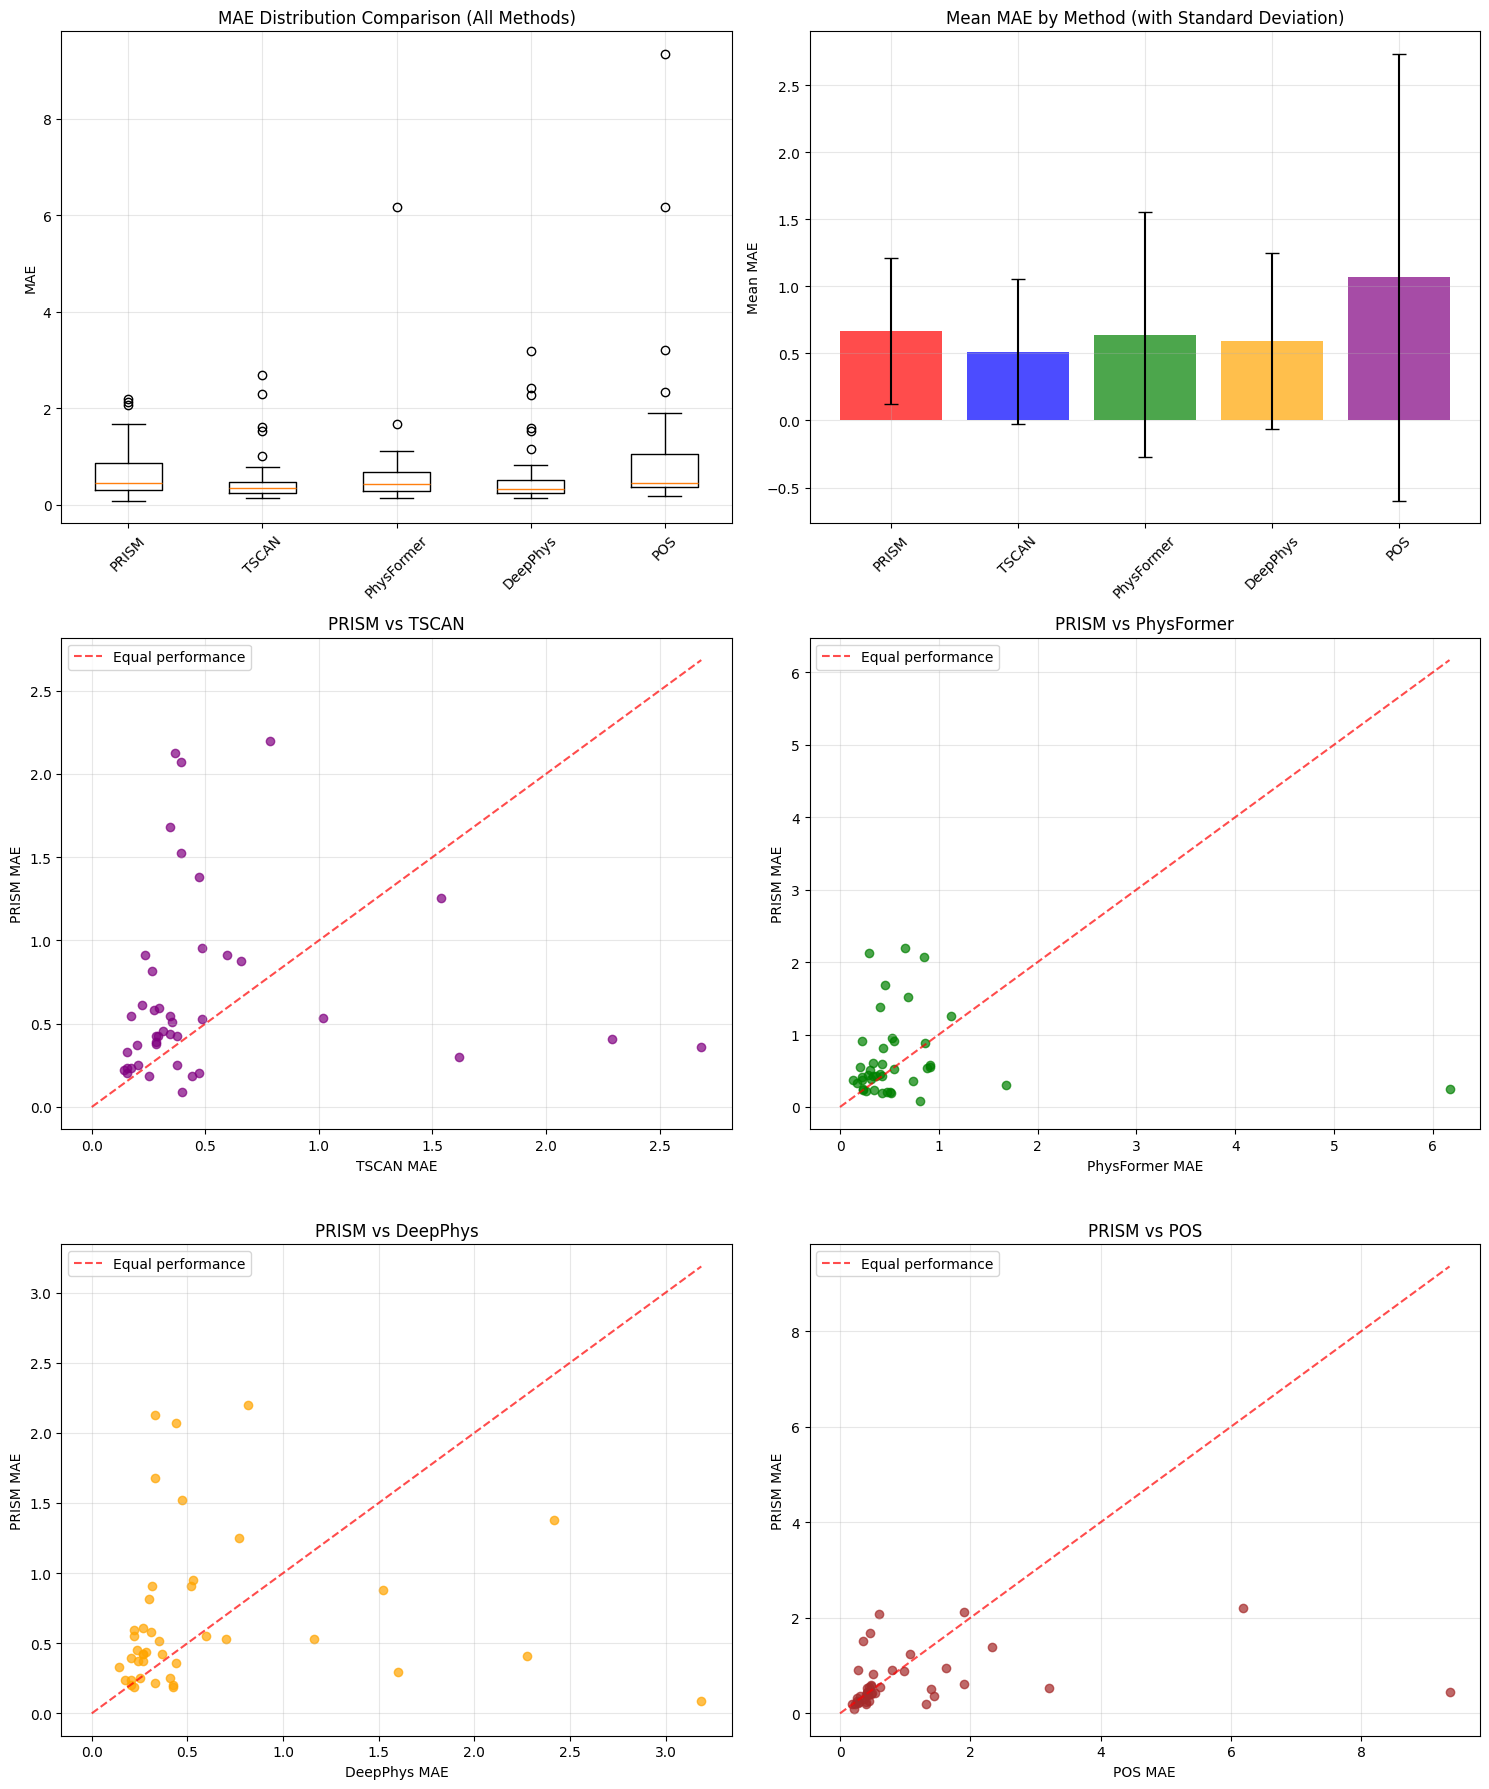

=== OVERALL CONCLUSIONS ===
Mean MAE by method:
PRISM: 0.6650
TSCAN: 0.5139
PhysFormer: 0.6392
DeepPhys: 0.5950
POS: 1.0690

Methods ranked by performance (best to worst):
1. TSCAN: 0.5139
2. DeepPhys: 0.5950
3. PhysFormer: 0.6392
4. PRISM: 0.6650
5. POS: 1.0690

=== PRISM PERFORMANCE SUMMARY ===
PRISM ranked #4 out of 5 methods
PRISM does not significantly outperform other methods after Bonferroni correction
PRISM mean MAE: 0.6650
Best performing method: TSCAN (MAE: 0.5139)

=== ADDITIONAL STATISTICAL INSIGHTS ===
No significant differences found (p < 0.05)

Effect sizes (Cohen's d) for PRISM comparisons:
  - vs TSCAN: d = 0.200 (small, PRISM better)
  - vs PhysFormer: d = 0.024 (negligible, PRISM better)
  - vs DeepPhys: d = 0.084 (negligible, PRISM better)
  - vs POS: d = -0.252 (small, Other better)


<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

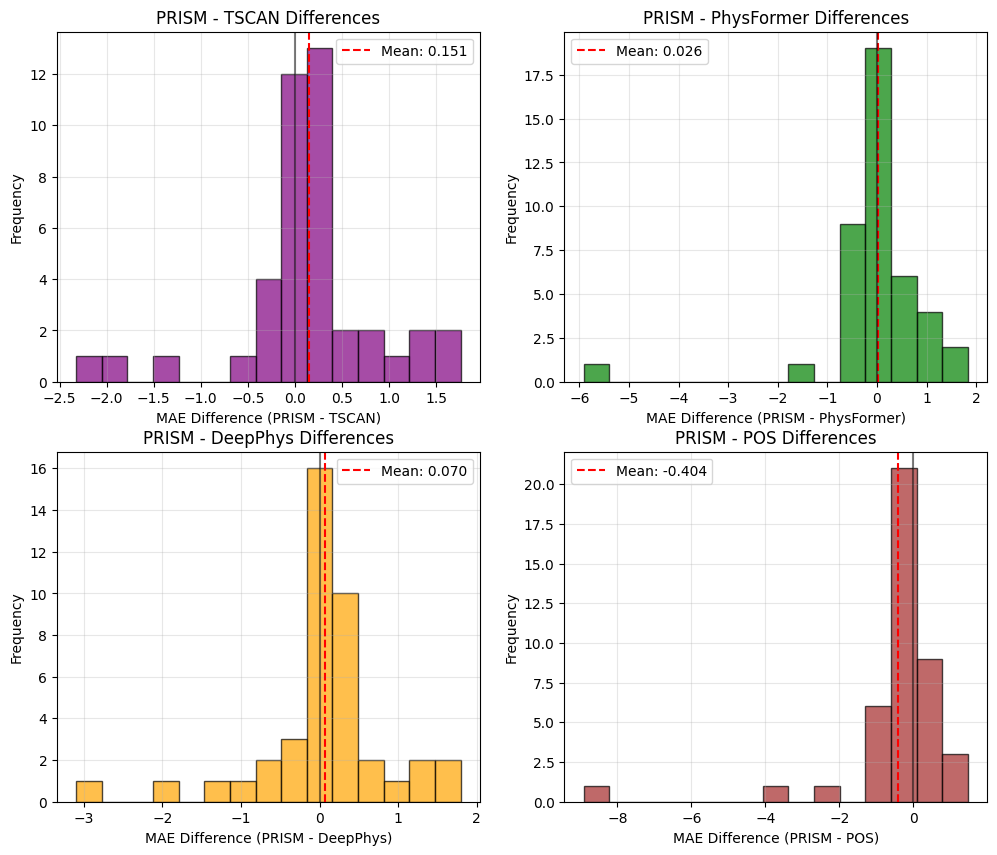

In [20]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_rel
import matplotlib.pyplot as plt

# PRISM data
prism_data = {
    'name': ['subject1', 'subject10', 'subject11', 'subject12', 'subject13', 'subject14', 
             'subject15', 'subject16', 'subject17', 'subject18', 'subject20', 'subject22',
             'subject23', 'subject24', 'subject25', 'subject26', 'subject27', 'subject3',
             'subject30', 'subject31', 'subject32', 'subject33', 'subject34', 'subject35',
             'subject36', 'subject37', 'subject38', 'subject39', 'subject4', 'subject40',
             'subject41', 'subject42', 'subject43', 'subject44', 'subject45', 'subject46',
             'subject47', 'subject48', 'subject49', 'subject5', 'subject8', 'subject9'],
    'mae_ours': [0.9521484375, 0.8161272321, 0.439453125, 0.3609793527, 0.9102957589, 0.87890625,
                 0.4080636161, 0.5493164063, 0.2511160714, 0.4237583705, 0.204031808, 0.4237583705,
                 0.4237583705, 1.381138393, 0.3735351563, 0.52734375, 1.252441406, 2.124023438,
                 1.522391183, 0.235421317, 0.6120954241, 0.1883370536, 0.3295898438, 0.2982003348,
                 0.3766741071, 0.2511160714, 0.204031808, 1.679338728, 0.087890625, 0.2197265625,
                 2.197265625, 0.1883370536, 0.4551478795, 0.5336216518, 0.5964006696, 2.071707589,
                 0.3923688616, 0.5807059152, 0.9102957589, 0.5126953125, 0.235421317, 0.5493164063]
}

# TSCAN data
tscan_data = {
    'participant_id': ['subject1', 'subject10', 'subject11', 'subject12', 'subject13', 'subject14',
                       'subject15', 'subject16', 'subject17', 'subject18', 'subject20', 'subject22',
                       'subject23', 'subject24', 'subject25', 'subject26', 'subject27', 'subject3',
                       'subject30', 'subject31', 'subject32', 'subject33', 'subject34', 'subject35',
                       'subject36', 'subject37', 'subject38', 'subject39', 'subject4', 'subject40',
                       'subject41', 'subject42', 'subject43', 'subject44', 'subject45', 'subject46',
                       'subject47', 'subject48', 'subject49', 'subject5', 'subject8', 'subject9'],
    'MAE': [0.4833984375, 0.266810825892857, 0.345284598214286, 2.68380301339286, 0.235421316964286, 0.6591796875,
            2.29143415178571, 0.172642299107143, 0.204031808035714, 0.376674107142857, 0.470842633928571, 0.282505580357143,
            0.29296875, 0.470842633928571, 0.19775390625, 0.4833984375, 1.5380859375, 0.3662109375,
            0.392368861607143, 0.172642299107143, 0.2197265625, 0.251116071428571, 0.156947544642857, 1.61655970982143,
            0.282505580357143, 0.376674107142857, 0.156947544642857, 0.345284598214286, 0.3955078125, 0.141252790178571,
            0.784737723214286, 0.439453125, 0.313895089285714, 1.02015904017857, 0.298200334821429, 0.392368861607143,
            0.282505580357143, 0.274658203125, 0.596400669642857, 0.3515625, 0.156947544642857, 0.345284598214286]
}

# PhysFormer data
physformer_data = {
    'participant_id': ['subject1', 'subject10', 'subject11', 'subject12', 'subject13', 'subject14',
                       'subject15', 'subject16', 'subject17', 'subject18', 'subject20', 'subject22',
                       'subject23', 'subject24', 'subject25', 'subject26', 'subject27', 'subject3',
                       'subject30', 'subject31', 'subject32', 'subject33', 'subject34', 'subject35',
                       'subject36', 'subject37', 'subject38', 'subject39', 'subject4', 'subject40',
                       'subject41', 'subject42', 'subject43', 'subject44', 'subject45', 'subject46',
                       'subject47', 'subject48', 'subject49', 'subject5', 'subject8', 'subject9'],
    'MAE': [0.52734375, 0.439453125, 0.282505580357143, 0.737653459821429, 0.2197265625, 0.863211495535714,
            0.2197265625, 0.204031808035714, 0.235421316964286, 0.32958984375, 0.470842633928571, 0.423758370535714,
            0.360979352678571, 0.408063616071429, 0.1318359375, 0.54931640625, 1.12060546875, 0.29296875,
            0.690569196428571, 0.235421316964286, 0.32958984375, 0.423758370535714, 0.172642299107143, 1.67933872767857,
            0.2197265625, 6.16803850446429, 0.502232142857143, 0.455147879464286, 0.81298828125, 0.266810825892857,
            0.6591796875, 0.517926897321429, 0.408063616071429, 0.87890625, 0.423758370535714, 0.847516741071429,
            0.313895089285714, 0.910295758928571, 0.54931640625, 0.3076171875, 0.345284598214286, 0.910295758928571]
}

# DeepPhys data
deepphys_data = {
    'participant_id': ['subject1', 'subject10', 'subject11', 'subject12', 'subject13', 'subject14',
                       'subject15', 'subject16', 'subject17', 'subject18', 'subject20', 'subject22',
                       'subject23', 'subject24', 'subject25', 'subject26', 'subject27', 'subject3',
                       'subject30', 'subject31', 'subject32', 'subject33', 'subject34', 'subject35',
                       'subject36', 'subject37', 'subject38', 'subject39', 'subject4', 'subject40',
                       'subject41', 'subject42', 'subject43', 'subject44', 'subject45', 'subject46',
                       'subject47', 'subject48', 'subject49', 'subject5', 'subject8', 'subject9'],
    'MAE': [0.52734375, 0.298200334821429, 0.282505580357143, 0.439453125, 0.313895089285714, 1.52239118303571,
            2.27573939732143, 0.2197265625, 0.251116071428571, 0.266810825892857, 0.423758370535714, 0.266810825892857,
            0.3662109375, 2.4169921875, 0.24169921875, 0.703125, 0.76904296875, 0.32958984375,
            0.470842633928571, 0.172642299107143, 0.266810825892857, 0.2197265625, 0.141252790178571, 1.60086495535714,
            0.266810825892857, 0.408063616071429, 0.204031808035714, 0.32958984375, 3.18603515625, 0.32958984375,
            0.816127232142857, 0.423758370535714, 0.235421316964286, 1.16141183035714, 0.2197265625, 0.439453125,
            0.204031808035714, 0.311279296875, 0.517926897321429, 0.3515625, 0.204031808035714, 0.596400669642857]
}

# POS data
pos_data = {
    'participant_id': ['subject1', 'subject10', 'subject11', 'subject12', 'subject13', 'subject14',
                       'subject15', 'subject16', 'subject17', 'subject18', 'subject20', 'subject22',
                       'subject23', 'subject24', 'subject25', 'subject26', 'subject27', 'subject3',
                       'subject30', 'subject31', 'subject32', 'subject33', 'subject34', 'subject35',
                       'subject36', 'subject37', 'subject38', 'subject39', 'subject4', 'subject40',
                       'subject41', 'subject42', 'subject43', 'subject44', 'subject45', 'subject46',
                       'subject47', 'subject48', 'subject49', 'subject5', 'subject8', 'subject9'],
    'MAE': [1.629638671875, 0.502232142857143, 9.35407366071429, 1.44391741071429, 0.282505580357143, 0.98876953125,
            0.470842633928571, 0.439453125, 0.266810825892857, 0.486537388392857, 1.318359375, 0.533621651785714,
            0.408063616071429, 2.33851841517857, 0.3076171875, 0.41748046875, 1.07666015625, 1.904296875,
            0.345284598214286, 0.298200334821429, 1.89906529017857, 0.392368861607143, 0.266810825892857, 0.360979352678571,
            0.423758370535714, 0.439453125, 0.188337053571429, 0.455147879464286, 0.2197265625, 0.282505580357143,
            6.18373325892857, 0.235421316964286, 0.408063616071429, 3.20172991071429, 0.470842633928571, 0.596400669642857,
            0.392368861607143, 0.470842633928571, 0.800432477678571, 1.3916015625, 0.392368861607143, 0.612095424107143]
}

# Create DataFrames
prism_df = pd.DataFrame(prism_data)
tscan_df = pd.DataFrame(tscan_data)
physformer_df = pd.DataFrame(physformer_data)
deepphys_df = pd.DataFrame(deepphys_data)
pos_df = pd.DataFrame(pos_data)

print("Data shapes:")
print(f"PRISM: {prism_df.shape}")
print(f"TSCAN: {tscan_df.shape}")
print(f"PhysFormer: {physformer_df.shape}")
print(f"DeepPhys: {deepphys_df.shape}")
print(f"POS: {pos_df.shape}")
print()

# Merge all data
merged_df = pd.merge(prism_df, tscan_df, left_on='name', right_on='participant_id', how='inner')
merged_df = pd.merge(merged_df, physformer_df, left_on='name', right_on='participant_id', 
                     how='inner', suffixes=('_tscan', '_physformer'))
merged_df = pd.merge(merged_df, deepphys_df, left_on='name', right_on='participant_id',
                     how='inner')
merged_df = pd.merge(merged_df, pos_df, left_on='name', right_on='participant_id',
                     how='inner', suffixes=('_deepphys', '_pos'))

print(f"Number of matched participants across all methods: {len(merged_df)}")
print()

# Extract values
prism_mae = merged_df['mae_ours'].values
tscan_mae = merged_df['MAE_tscan'].values
physformer_mae = merged_df['MAE_physformer'].values
deepphys_mae = merged_df['MAE_deepphys'].values
pos_mae = merged_df['MAE_pos'].values

def perform_paired_ttest(method1_values, method2_values, method1_name, method2_name):
    """Perform paired t-test and return comprehensive results"""
    
    # Perform paired t-test
    t_stat, p_value = ttest_rel(method1_values, method2_values)
    
    # Calculate descriptive statistics
    method1_mean = np.mean(method1_values)
    method2_mean = np.mean(method2_values)
    method1_std = np.std(method1_values)
    method2_std = np.std(method2_values)
    
    # Calculate difference statistics
    differences = method1_values - method2_values
    mean_diff = np.mean(differences)
    std_diff = np.std(differences)
    
    # Calculate effect size (Cohen's d for paired samples)
    if std_diff == 0:
        cohens_d = 0
    else:
        cohens_d = mean_diff / std_diff
    
    # Calculate 95% confidence interval for the mean difference
    from scipy import stats
    se_diff = std_diff / np.sqrt(len(differences))
    ci_lower, ci_upper = stats.t.interval(0.95, len(differences)-1, mean_diff, se_diff)
    
    # Count wins
    method1_wins = np.sum(differences < 0)  # Method 1 has lower error (better)
    method2_wins = np.sum(differences > 0)  # Method 2 has lower error (better)
    ties = np.sum(differences == 0)
    
    return {
        'method1_name': method1_name,
        'method2_name': method2_name,
        'n_pairs': len(method1_values),
        'method1_mean': method1_mean,
        'method2_mean': method2_mean,
        'method1_std': method1_std,
        'method2_std': method2_std,
        'mean_diff': mean_diff,
        'std_diff': std_diff,
        'se_diff': se_diff,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        't_stat': t_stat,
        'p_value': p_value,
        'cohens_d': cohens_d,
        'method1_wins': method1_wins,
        'method2_wins': method2_wins,
        'ties': ties,
        'differences': differences
    }

def print_ttest_results(results):
    """Print formatted t-test results"""
    r = results
    print(f"=== PAIRED T-TEST: {r['method1_name']} vs {r['method2_name']} ===")
    print(f"Number of paired participants: {r['n_pairs']}")
    print()
    
    print("Descriptive Statistics:")
    print(f"{r['method1_name']} MAE - Mean: {r['method1_mean']:.4f}, SD: {r['method1_std']:.4f}")
    print(f"{r['method2_name']} MAE - Mean: {r['method2_mean']:.4f}, SD: {r['method2_std']:.4f}")
    print()
    
    print(f"Difference Statistics ({r['method1_name']} - {r['method2_name']}):")
    print(f"Mean difference: {r['mean_diff']:.4f}")
    print(f"95% CI for mean difference: [{r['ci_lower']:.4f}, {r['ci_upper']:.4f}]")
    print()
    
    print("Statistical Test Results:")
    print(f"t-statistic: {r['t_stat']:.4f}")
    print(f"p-value: {r['p_value']:.6f}")
    print(f"Cohen's d (effect size): {r['cohens_d']:.4f}")
    print()
    
    # Effect size interpretation
    if abs(r['cohens_d']) < 0.2:
        effect_size = "negligible"
    elif abs(r['cohens_d']) < 0.5:
        effect_size = "small"
    elif abs(r['cohens_d']) < 0.8:
        effect_size = "medium"
    else:
        effect_size = "large"
    
    print(f"Effect size: {effect_size} (|Cohen's d| = {abs(r['cohens_d']):.3f})")
    
    # Significance interpretation
    if r['p_value'] < 0.001:
        significance = "highly significant (p < 0.001)"
    elif r['p_value'] < 0.01:
        significance = "very significant (p < 0.01)"
    elif r['p_value'] < 0.05:
        significance = "significant (p < 0.05)"
    else:
        significance = "not significant (p ≥ 0.05)"
    
    print(f"Statistical significance: {significance}")
    
    # Performance interpretation
    if r['mean_diff'] < 0:
        better_method = f"{r['method1_name']} performs better (lower MAE)"
    elif r['mean_diff'] > 0:
        better_method = f"{r['method2_name']} performs better (lower MAE)"
    else:
        better_method = "No difference in performance"
    
    print(f"Performance: {better_method}")
    print()
    
    print("Individual Participant Wins:")
    total = r['method1_wins'] + r['method2_wins'] + r['ties']
    print(f"{r['method1_name']} better: {r['method1_wins']}/{total} ({r['method1_wins']/total*100:.1f}%)")
    print(f"{r['method2_name']} better: {r['method2_wins']}/{total} ({r['method2_wins']/total*100:.1f}%)")
    if r['ties'] > 0:
        print(f"Ties: {r['ties']}/{total} ({r['ties']/total*100:.1f}%)")
    print()

# Perform all pairwise comparisons with PRISM as baseline
print("PAIRWISE COMPARISONS WITH PRISM AS BASELINE\n")

# PRISM vs TSCAN
prism_tscan_results = perform_paired_ttest(prism_mae, tscan_mae, "PRISM", "TSCAN")
print_ttest_results(prism_tscan_results)

# PRISM vs PhysFormer
prism_physformer_results = perform_paired_ttest(prism_mae, physformer_mae, "PRISM", "PhysFormer")
print_ttest_results(prism_physformer_results)

# PRISM vs DeepPhys
prism_deepphys_results = perform_paired_ttest(prism_mae, deepphys_mae, "PRISM", "DeepPhys")
print_ttest_results(prism_deepphys_results)

# PRISM vs POS
prism_pos_results = perform_paired_ttest(prism_mae, pos_mae, "PRISM", "POS")
print_ttest_results(prism_pos_results)

# Multiple comparison correction (Bonferroni) - focusing on PRISM comparisons
prism_results = [prism_tscan_results, prism_physformer_results, prism_deepphys_results, prism_pos_results]
n_prism_comparisons = len(prism_results)
bonferroni_alpha_prism = 0.05 / n_prism_comparisons

print("=== MULTIPLE COMPARISON CORRECTION (PRISM COMPARISONS) ===")
print(f"Number of PRISM comparisons: {n_prism_comparisons}")
print(f"Bonferroni corrected α: {bonferroni_alpha_prism:.6f}")
print()

for result in prism_results:
    comparison = f"{result['method1_name']} vs {result['method2_name']}"
    significant = "Yes" if result['p_value'] < bonferroni_alpha_prism else "No"
    print(f"{comparison}: p = {result['p_value']:.6f}, Bonferroni significant: {significant}")
print()

# Summary table
print("=== SUMMARY TABLE (PRISM COMPARISONS) ===")
summary_data = []
for result in prism_results:
    summary_data.append({
        'Comparison': f"{result['method1_name']} vs {result['method2_name']}",
        'PRISM_Mean': result['method1_mean'],
        'Other_Mean': result['method2_mean'],
        'Mean_Diff': result['mean_diff'],
        'p_value': result['p_value'],
        'Cohens_d': result['cohens_d'],
        'Significant_05': "Yes" if result['p_value'] < 0.05 else "No",
        'Bonferroni_Sig': "Yes" if result['p_value'] < bonferroni_alpha_prism else "No",
        'PRISM_Wins': f"{result['method1_wins']}/{result['n_pairs']}"
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.round(4))
print()

# Create comprehensive visualization
fig, axes = plt.subplots(3, 2, figsize=(15, 18))

# Method comparison plots
methods = ['PRISM', 'TSCAN', 'PhysFormer', 'DeepPhys', 'POS']
mae_values = [prism_mae, tscan_mae, physformer_mae, deepphys_mae, pos_mae]
colors = ['red', 'blue', 'green', 'orange', 'purple']

# Plot 1: Box plot comparison of all methods
axes[0, 0].boxplot(mae_values, labels=methods)
axes[0, 0].set_ylabel('MAE')
axes[0, 0].set_title('MAE Distribution Comparison (All Methods)')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Bar chart of mean MAE with error bars
means = [np.mean(mae) for mae in mae_values]
stds = [np.std(mae) for mae in mae_values]
x_pos = range(len(methods))
bars = axes[0, 1].bar(x_pos, means, yerr=stds, capsize=5, color=colors, alpha=0.7)
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(methods, rotation=45)
axes[0, 1].set_ylabel('Mean MAE')
axes[0, 1].set_title('Mean MAE by Method (with Standard Deviation)')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Scatter plot PRISM vs TSCAN
axes[1, 0].scatter(tscan_mae, prism_mae, alpha=0.7, color='purple')
lim_max = max(max(prism_mae), max(tscan_mae))
axes[1, 0].plot([0, lim_max], [0, lim_max], 'r--', alpha=0.7, label='Equal performance')
axes[1, 0].set_xlabel('TSCAN MAE')
axes[1, 0].set_ylabel('PRISM MAE')
axes[1, 0].set_title('PRISM vs TSCAN')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Scatter plot PRISM vs PhysFormer
axes[1, 1].scatter(physformer_mae, prism_mae, alpha=0.7, color='green')
lim_max = max(max(prism_mae), max(physformer_mae))
axes[1, 1].plot([0, lim_max], [0, lim_max], 'r--', alpha=0.7, label='Equal performance')
axes[1, 1].set_xlabel('PhysFormer MAE')
axes[1, 1].set_ylabel('PRISM MAE')
axes[1, 1].set_title('PRISM vs PhysFormer')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Plot 5: Scatter plot PRISM vs DeepPhys
axes[2, 0].scatter(deepphys_mae, prism_mae, alpha=0.7, color='orange')
lim_max = max(max(prism_mae), max(deepphys_mae))
axes[2, 0].plot([0, lim_max], [0, lim_max], 'r--', alpha=0.7, label='Equal performance')
axes[2, 0].set_xlabel('DeepPhys MAE')
axes[2, 0].set_ylabel('PRISM MAE')
axes[2, 0].set_title('PRISM vs DeepPhys')
axes[2, 0].legend()
axes[2, 0].grid(True, alpha=0.3)

# Plot 6: Scatter plot PRISM vs POS
axes[2, 1].scatter(pos_mae, prism_mae, alpha=0.7, color='brown')
lim_max = max(max(prism_mae), max(pos_mae))
axes[2, 1].plot([0, lim_max], [0, lim_max], 'r--', alpha=0.7, label='Equal performance')
axes[2, 1].set_xlabel('POS MAE')
axes[2, 1].set_ylabel('PRISM MAE')
axes[2, 1].set_title('PRISM vs POS')
axes[2, 1].legend()
axes[2, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Overall summary
print("=== OVERALL CONCLUSIONS ===")
print("Mean MAE by method:")
method_means = {
    'PRISM': np.mean(prism_mae),
    'TSCAN': np.mean(tscan_mae), 
    'PhysFormer': np.mean(physformer_mae),
    'DeepPhys': np.mean(deepphys_mae),
    'POS': np.mean(pos_mae)
}

for method, mae in method_means.items():
    print(f"{method}: {mae:.4f}")
print()

# Rank methods by performance
ranked_methods = sorted(method_means.items(), key=lambda x: x[1])
print("Methods ranked by performance (best to worst):")
for i, (method, mae) in enumerate(ranked_methods, 1):
    print(f"{i}. {method}: {mae:.4f}")
print()

# PRISM performance summary
print("=== PRISM PERFORMANCE SUMMARY ===")
prism_rank = [i for i, (method, _) in enumerate(ranked_methods, 1) if method == 'PRISM'][0]
print(f"PRISM ranked #{prism_rank} out of {len(methods)} methods")

prism_significant_wins = []
for result in prism_results:
    if result['p_value'] < bonferroni_alpha_prism and result['mean_diff'] < 0:
        prism_significant_wins.append(result['method2_name'])

if prism_significant_wins:
    print(f"PRISM significantly outperforms: {', '.join(prism_significant_wins)} (Bonferroni corrected)")
else:
    print("PRISM does not significantly outperform other methods after Bonferroni correction")

print(f"PRISM mean MAE: {method_means['PRISM']:.4f}")
print(f"Best performing method: {ranked_methods[0][0]} (MAE: {ranked_methods[0][1]:.4f})")

# Additional statistical insights
print("\n=== ADDITIONAL STATISTICAL INSIGHTS ===")

# Check which methods have significant advantages without correction
uncorrected_wins = []
for result in prism_results:
    if result['p_value'] < 0.05:
        if result['mean_diff'] < 0:
            uncorrected_wins.append(f"PRISM > {result['method2_name']}")
        else:
            uncorrected_wins.append(f"{result['method2_name']} > PRISM")

if uncorrected_wins:
    print("Significant differences (p < 0.05, uncorrected):")
    for win in uncorrected_wins:
        print(f"  - {win}")
else:
    print("No significant differences found (p < 0.05)")

# Effect size summary
print("\nEffect sizes (Cohen's d) for PRISM comparisons:")
for result in prism_results:
    direction = "PRISM better" if result['cohens_d'] > 0 else "Other better"
    magnitude = "large" if abs(result['cohens_d']) >= 0.8 else "medium" if abs(result['cohens_d']) >= 0.5 else "small" if abs(result['cohens_d']) >= 0.2 else "negligible"
    print(f"  - vs {result['method2_name']}: d = {result['cohens_d']:.3f} ({magnitude}, {direction})")
()
plt.show()

# Create a second figure for difference distributions
fig2, axes2 = plt.subplots(2, 2, figsize=(12, 10))

# Plot difference distributions for PRISM comparisons
axes2[0, 0].hist(prism_tscan_results['differences'], bins=15, alpha=0.7, edgecolor='black', color='purple')
axes2[0, 0].axvline(prism_tscan_results['mean_diff'], color='red', linestyle='--', 
                   label=f'Mean: {prism_tscan_results["mean_diff"]:.3f}')
axes2[0, 0].axvline(0, color='black', linestyle='-', alpha=0.5)
axes2[0, 0].set_xlabel('MAE Difference (PRISM - TSCAN)')
axes2[0, 0].set_ylabel('Frequency')
axes2[0, 0].set_title('PRISM - TSCAN Differences')
axes2[0, 0].legend()
axes2[0, 0].grid(True, alpha=0.3)

axes2[0, 1].hist(prism_physformer_results['differences'], bins=15, alpha=0.7, edgecolor='black', color='green')
axes2[0, 1].axvline(prism_physformer_results['mean_diff'], color='red', linestyle='--',
                   label=f'Mean: {prism_physformer_results["mean_diff"]:.3f}')
axes2[0, 1].axvline(0, color='black', linestyle='-', alpha=0.5)
axes2[0, 1].set_xlabel('MAE Difference (PRISM - PhysFormer)')
axes2[0, 1].set_ylabel('Frequency')
axes2[0, 1].set_title('PRISM - PhysFormer Differences')
axes2[0, 1].legend()
axes2[0, 1].grid(True, alpha=0.3)

axes2[1, 0].hist(prism_deepphys_results['differences'], bins=15, alpha=0.7, edgecolor='black', color='orange')
axes2[1, 0].axvline(prism_deepphys_results['mean_diff'], color='red', linestyle='--',
                   label=f'Mean: {prism_deepphys_results["mean_diff"]:.3f}')
axes2[1, 0].axvline(0, color='black', linestyle='-', alpha=0.5)
axes2[1, 0].set_xlabel('MAE Difference (PRISM - DeepPhys)')
axes2[1, 0].set_ylabel('Frequency')
axes2[1, 0].set_title('PRISM - DeepPhys Differences')
axes2[1, 0].legend()
axes2[1, 0].grid(True, alpha=0.3)

axes2[1, 1].hist(prism_pos_results['differences'], bins=15, alpha=0.7, edgecolor='black', color='brown')
axes2[1, 1].axvline(prism_pos_results['mean_diff'], color='red', linestyle='--',
                   label=f'Mean: {prism_pos_results["mean_diff"]:.3f}')
axes2[1, 1].axvline(0, color='black', linestyle='-', alpha=0.5)
axes2[1, 1].set_xlabel('MAE Difference (PRISM - POS)')
axes2[1, 1].set_ylabel('Frequency')
axes2[1, 1].set_title('PRISM - POS Differences')
axes2[1, 1].legend()
axes2[1, 1].grid(True, alpha=0.3)

plt.tight_layout